# Exploración del Entorno CartPole-v1

Este notebook contiene la exploración inicial del entorno CartPole-v1 de Gymnasium, necesaria para comprender el espacio de observaciones y diseñar una estrategia de discretización adecuada para la implementación de Q-Learning.

## Importación de librerías

In [ ]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [4]:
# Inicializar el entorno en modo sin visualización para análisis
env = gym.make('CartPole-v1', render_mode=None)

## Análisis del espacio de observaciones

El espacio de observaciones de CartPole-v1 es continuo y contiene 4 variables.

In [5]:
print("Espacio de observaciones:", env.observation_space)
print("Límites inferiores:", env.observation_space.low)
print("Límites superiores:", env.observation_space.high)

Espacio de observaciones: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Límites inferiores: [-4.8               -inf -0.41887903        -inf]
Límites superiores: [4.8               inf 0.41887903        inf]


## Análisis del espacio de acciones

El espacio de acciones determina los movimientos que puede realizar el agente.

In [6]:
print("Espacio de acciones:", env.action_space)
print("Número de acciones:", env.action_space.n)
print("Acción 0: Empujar el carro hacia la izquierda")
print("Acción 1: Empujar el carro hacia la derecha")

Espacio de acciones: Discrete(2)
Número de acciones: 2
Acción 0: Empujar el carro hacia la izquierda
Acción 1: Empujar el carro hacia la derecha


## Exploración de rangos reales de las variables

Dado que los límites teóricos del espacio de observaciones incluyen infinitos, es necesario ejecutar episodios aleatorios para determinar los rangos reales que toman las variables durante el juego. Esta información será fundamental para diseñar una discretización efectiva.

In [7]:
# Ejecutar episodios aleatorios para observar los rangos reales
num_episodes = 100
observations = []

for episode in range(num_episodes):
    obs, _ = env.reset()
    done = False
    
    while not done:
        observations.append(obs)
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

observations = np.array(observations)

# Calcular estadísticas de cada variable
variables = ['Posición del carro', 'Velocidad del carro', 'Ángulo del poste', 'Velocidad angular del poste']
print("Estadísticas de las variables observadas en {} episodios aleatorios:\n".format(num_episodes))

for i, var_name in enumerate(variables):
    print(f"{var_name}:")
    print(f"  Mínimo: {observations[:, i].min():.4f}")
    print(f"  Máximo: {observations[:, i].max():.4f}")
    print(f"  Media: {observations[:, i].mean():.4f}")
    print(f"  Desviación estándar: {observations[:, i].std():.4f}")
    print()

Estadísticas de las variables observadas en 100 episodios aleatorios:

Posición del carro:
  Mínimo: -0.5276
  Máximo: 0.3375
  Media: -0.0065
  Desviación estándar: 0.0805

Velocidad del carro:
  Mínimo: -1.7941
  Máximo: 1.7331
  Media: 0.0233
  Desviación estándar: 0.5264

Ángulo del poste:
  Mínimo: -0.2089
  Máximo: 0.2091
  Media: -0.0020
  Desviación estándar: 0.0902

Velocidad angular del poste:
  Mínimo: -2.7176
  Máximo: 2.6004
  Media: -0.0453
  Desviación estándar: 0.7723



## Análisis de criticidad de las variables

Según la documentación de CartPole-v1, el episodio termina cuando:
- La posición del carro excede ±2.4 unidades
- El ángulo del poste excede ±12 grados (≈ ±0.2095 radianes)

Las variables relacionadas con el ángulo del poste son críticas para mantener el equilibrio, mientras que la posición del carro tiene un margen más amplio.

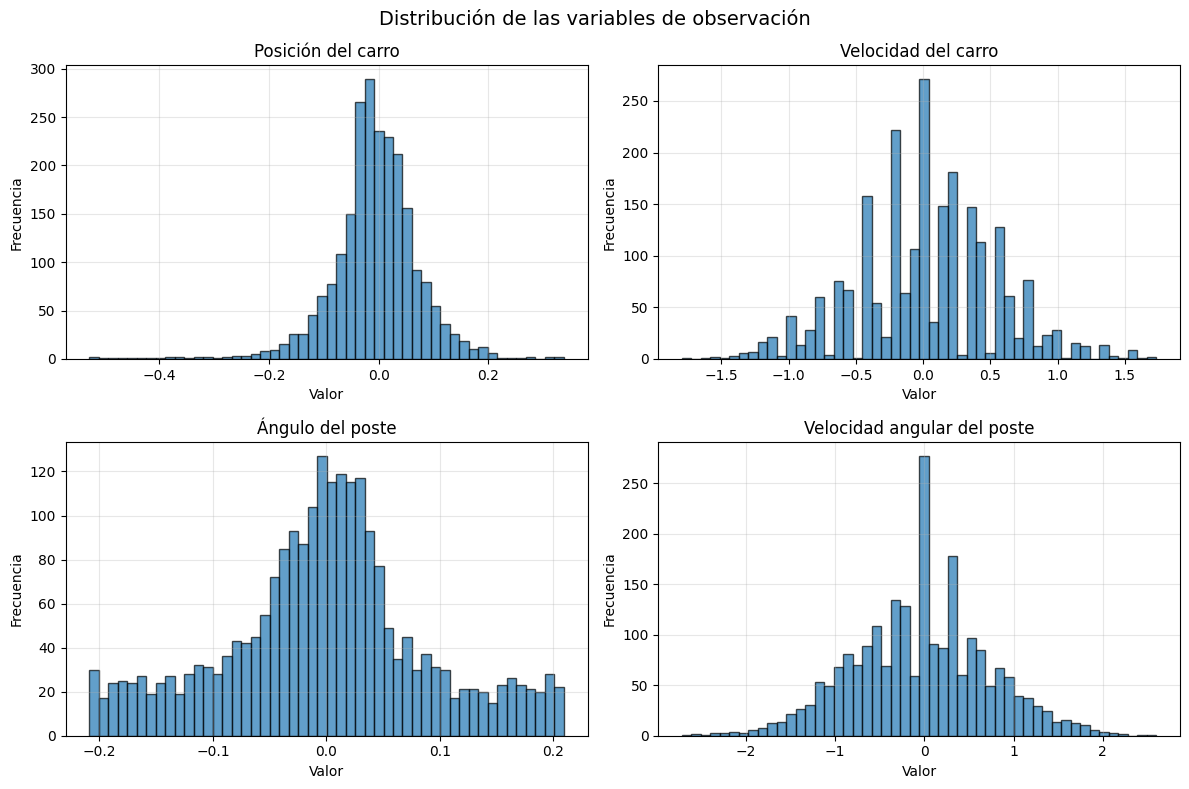

In [8]:
# Visualizar distribución de las variables
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribución de las variables de observación', fontsize=14)

for i, (var_name, ax) in enumerate(zip(variables, axes.flatten())):
    ax.hist(observations[:, i], bins=50, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.set_title(var_name)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Determinar rangos prácticos para discretización
# Usaremos percentiles para evitar valores extremos que rara vez ocurren

print("Rangos recomendados para discretización (basados en percentiles 1-99):\n")

for i, var_name in enumerate(variables):
    p1 = np.percentile(observations[:, i], 1)
    p99 = np.percentile(observations[:, i], 99)
    print(f"{var_name}:")
    print(f"  Rango sugerido: [{p1:.4f}, {p99:.4f}]")
    print()

Rangos recomendados para discretización (basados en percentiles 1-99):

Posición del carro:
  Rango sugerido: [-0.2512, 0.1869]

Velocidad del carro:
  Rango sugerido: [-1.2075, 1.3343]

Ángulo del poste:
  Rango sugerido: [-0.2022, 0.2003]

Velocidad angular del poste:
  Rango sugerido: [-1.8675, 1.8119]



## Conclusiones de la exploración

Los resultados de esta exploración nos permiten establecer:

1. **Variables críticas**: Ángulo del poste y velocidad angular del poste requieren mayor resolución en la discretización debido a su impacto directo en el equilibrio.

2. **Variables no críticas**: Posición y velocidad del carro pueden discretizarse con menos bins sin perder información esencial.

3. **Estrategia de discretización**: Se implementarán dos versiones:
   - Discretización gruesa: 3 bins para variables no críticas, 6 bins para variables críticas
   - Discretización fina: 6 bins para variables no críticas, 12 bins para variables críticas

## Definición de rangos óptimos para discretización

Basándonos en el análisis realizado, los límites de terminación del entorno y las mejores prácticas, se establecen los siguientes rangos para la discretización:

In [11]:
# Definición de rangos para discretización
# Estos rangos serán utilizados en las implementaciones de Q-Learning

# Variables NO CRÍTICAS (menor impacto en terminación del episodio)
cart_position_range = (-2.4, 2.4)        # Límite exacto de terminación del entorno
cart_velocity_range = (-3.0, 3.0)        # Rango amplio que cubre comportamiento de políticas entrenadas

# Variables CRÍTICAS (impacto directo en equilibrio del poste)
pole_angle_range = (-0.21, 0.21)         # Límite exacto de terminación (±12 grados)
pole_angular_velocity_range = (-3.5, 3.5)  # Rango que captura estados de alta velocidad angular

print("Rangos definidos para discretización:\n")
print(f"Posición del carro: {cart_position_range}")
print(f"Velocidad del carro: {cart_velocity_range}")
print(f"Ángulo del poste: {pole_angle_range}")
print(f"Velocidad angular del poste: {pole_angular_velocity_range}")

Rangos definidos para discretización:

Posición del carro: (-2.4, 2.4)
Velocidad del carro: (-3.0, 3.0)
Ángulo del poste: (-0.21, 0.21)
Velocidad angular del poste: (-3.5, 3.5)


### Justificación de los rangos seleccionados

**Posición del carro** `[-2.4, 2.4]`:
- Corresponde al límite exacto de terminación del entorno
- Aunque en episodios aleatorios no se exploró completamente, un agente entrenado necesitará acceder a todo el rango

**Velocidad del carro** `[-3.0, 3.0]`:
- Rango observado en episodios aleatorios: aproximadamente ±1.9
- Se amplía para capturar velocidades mayores que puede desarrollar un agente entrenado
- Valor conservador que equilibra cobertura y eficiencia de la tabla Q

**Ángulo del poste** `[-0.21, 0.21]` rad (±12°):
- Variable más crítica: el episodio termina si se excede este límite
- Usar el límite exacto asegura que todos los estados válidos estén representados
- Requiere mayor resolución en la discretización

**Velocidad angular del poste** `[-3.5, 3.5]` rad/s:
- Segunda variable crítica: determina si el poste se recupera o continúa cayendo
- Rango observado: aproximadamente ±2.5
- Se amplía para capturar situaciones límite donde el agente debe realizar correcciones agresivas
- Requiere mayor resolución en la discretización

# Implementación de Discretización

En esta sección se implementan dos estrategias de discretización para convertir el espacio de observaciones continuo en estados discretos que permitan la aplicación de Q-Learning.

## Discretización Gruesa

Esta discretización utiliza menor resolución para crear un espacio de estados más compacto:
- Variables no críticas (posición y velocidad del carro): 3 bins
- Variables críticas (ángulo y velocidad angular del poste): 6 bins
- Espacio de estados total: 3 × 3 × 6 × 6 = 324 estados

In [12]:
# Crear bins para discretización gruesa
n_bins_cart_pos_coarse = 3
n_bins_cart_vel_coarse = 3
n_bins_pole_angle_coarse = 6
n_bins_pole_ang_vel_coarse = 6

# Generar los límites de los bins usando linspace
cart_pos_bins_coarse = np.linspace(cart_position_range[0], cart_position_range[1], n_bins_cart_pos_coarse + 1)
cart_vel_bins_coarse = np.linspace(cart_velocity_range[0], cart_velocity_range[1], n_bins_cart_vel_coarse + 1)
pole_angle_bins_coarse = np.linspace(pole_angle_range[0], pole_angle_range[1], n_bins_pole_angle_coarse + 1)
pole_ang_vel_bins_coarse = np.linspace(pole_angular_velocity_range[0], pole_angular_velocity_range[1], n_bins_pole_ang_vel_coarse + 1)

print("Discretización Gruesa:")
print(f"Total de estados: {n_bins_cart_pos_coarse * n_bins_cart_vel_coarse * n_bins_pole_angle_coarse * n_bins_pole_ang_vel_coarse}")
print(f"\nBins por variable:")
print(f"  Posición del carro: {n_bins_cart_pos_coarse} bins")
print(f"  Velocidad del carro: {n_bins_cart_vel_coarse} bins")
print(f"  Ángulo del poste: {n_bins_pole_angle_coarse} bins")
print(f"  Velocidad angular del poste: {n_bins_pole_ang_vel_coarse} bins")

Discretización Gruesa:
Total de estados: 324

Bins por variable:
  Posición del carro: 3 bins
  Velocidad del carro: 3 bins
  Ángulo del poste: 6 bins
  Velocidad angular del poste: 6 bins


In [13]:
# Función para discretizar observaciones (versión gruesa)
def discretize_observation_coarse(observation):
    """
    Convierte una observación continua en un estado discreto usando discretización gruesa.
    
    Args:
        observation: Array de 4 elementos con [posición, velocidad, ángulo, velocidad_angular]
    
    Returns:
        Tupla de 4 enteros representando el estado discreto
    """
    cart_pos, cart_vel, pole_angle, pole_ang_vel = observation
    
    # Usar digitize para encontrar el bin correspondiente (restamos 1 para indexar desde 0)
    cart_pos_idx = np.digitize(cart_pos, cart_pos_bins_coarse[1:-1])
    cart_vel_idx = np.digitize(cart_vel, cart_vel_bins_coarse[1:-1])
    pole_angle_idx = np.digitize(pole_angle, pole_angle_bins_coarse[1:-1])
    pole_ang_vel_idx = np.digitize(pole_ang_vel, pole_ang_vel_bins_coarse[1:-1])
    
    return (cart_pos_idx, cart_vel_idx, pole_angle_idx, pole_ang_vel_idx)

In [14]:
# Verificar funcionamiento de la discretización gruesa
test_obs, _ = env.reset()
print("Observación continua de prueba:")
print(f"  Posición: {test_obs[0]:.4f}")
print(f"  Velocidad: {test_obs[1]:.4f}")
print(f"  Ángulo: {test_obs[2]:.4f}")
print(f"  Velocidad angular: {test_obs[3]:.4f}")

test_state = discretize_observation_coarse(test_obs)
print(f"\nEstado discreto resultante: {test_state}")
print(f"Índices válidos: cart_pos[0-{n_bins_cart_pos_coarse-1}], cart_vel[0-{n_bins_cart_vel_coarse-1}], pole_angle[0-{n_bins_pole_angle_coarse-1}], pole_ang_vel[0-{n_bins_pole_ang_vel_coarse-1}]")

Observación continua de prueba:
  Posición: 0.0321
  Velocidad: 0.0214
  Ángulo: 0.0437
  Velocidad angular: 0.0159

Estado discreto resultante: (np.int64(1), np.int64(1), np.int64(3), np.int64(3))
Índices válidos: cart_pos[0-2], cart_vel[0-2], pole_angle[0-5], pole_ang_vel[0-5]


## Discretización Fina

Esta discretización utiliza mayor resolución para capturar más detalles del espacio de estados:
- Variables no críticas (posición y velocidad del carro): 6 bins
- Variables críticas (ángulo y velocidad angular del poste): 12 bins
- Espacio de estados total: 6 × 6 × 12 × 12 = 5,184 estados

In [15]:
# Crear bins para discretización fina
n_bins_cart_pos_fine = 6
n_bins_cart_vel_fine = 6
n_bins_pole_angle_fine = 12
n_bins_pole_ang_vel_fine = 12

# Generar los límites de los bins usando linspace
cart_pos_bins_fine = np.linspace(cart_position_range[0], cart_position_range[1], n_bins_cart_pos_fine + 1)
cart_vel_bins_fine = np.linspace(cart_velocity_range[0], cart_velocity_range[1], n_bins_cart_vel_fine + 1)
pole_angle_bins_fine = np.linspace(pole_angle_range[0], pole_angle_range[1], n_bins_pole_angle_fine + 1)
pole_ang_vel_bins_fine = np.linspace(pole_angular_velocity_range[0], pole_angular_velocity_range[1], n_bins_pole_ang_vel_fine + 1)

print("Discretización Fina:")
print(f"Total de estados: {n_bins_cart_pos_fine * n_bins_cart_vel_fine * n_bins_pole_angle_fine * n_bins_pole_ang_vel_fine}")
print(f"\nBins por variable:")
print(f"  Posición del carro: {n_bins_cart_pos_fine} bins")
print(f"  Velocidad del carro: {n_bins_cart_vel_fine} bins")
print(f"  Ángulo del poste: {n_bins_pole_angle_fine} bins")
print(f"  Velocidad angular del poste: {n_bins_pole_ang_vel_fine} bins")

Discretización Fina:
Total de estados: 5184

Bins por variable:
  Posición del carro: 6 bins
  Velocidad del carro: 6 bins
  Ángulo del poste: 12 bins
  Velocidad angular del poste: 12 bins


In [16]:
# Función para discretizar observaciones (versión fina)
def discretize_observation_fine(observation):
    """
    Convierte una observación continua en un estado discreto usando discretización fina.
    
    Args:
        observation: Array de 4 elementos con [posición, velocidad, ángulo, velocidad_angular]
    
    Returns:
        Tupla de 4 enteros representando el estado discreto
    """
    cart_pos, cart_vel, pole_angle, pole_ang_vel = observation
    
    # Usar digitize para encontrar el bin correspondiente (restamos 1 para indexar desde 0)
    cart_pos_idx = np.digitize(cart_pos, cart_pos_bins_fine[1:-1])
    cart_vel_idx = np.digitize(cart_vel, cart_vel_bins_fine[1:-1])
    pole_angle_idx = np.digitize(pole_angle, pole_angle_bins_fine[1:-1])
    pole_ang_vel_idx = np.digitize(pole_ang_vel, pole_ang_vel_bins_fine[1:-1])
    
    return (cart_pos_idx, cart_vel_idx, pole_angle_idx, pole_ang_vel_idx)

In [17]:
# Verificar funcionamiento de la discretización fina
test_state_fine = discretize_observation_fine(test_obs)
print("Misma observación continua de prueba:")
print(f"  Posición: {test_obs[0]:.4f}")
print(f"  Velocidad: {test_obs[1]:.4f}")
print(f"  Ángulo: {test_obs[2]:.4f}")
print(f"  Velocidad angular: {test_obs[3]:.4f}")

print(f"\nEstado discreto resultante: {test_state_fine}")
print(f"Índices válidos: cart_pos[0-{n_bins_cart_pos_fine-1}], cart_vel[0-{n_bins_cart_vel_fine-1}], pole_angle[0-{n_bins_pole_angle_fine-1}], pole_ang_vel[0-{n_bins_pole_ang_vel_fine-1}]")

Misma observación continua de prueba:
  Posición: 0.0321
  Velocidad: 0.0214
  Ángulo: 0.0437
  Velocidad angular: 0.0159

Estado discreto resultante: (np.int64(3), np.int64(3), np.int64(7), np.int64(6))
Índices válidos: cart_pos[0-5], cart_vel[0-5], pole_angle[0-11], pole_ang_vel[0-11]


## Comparación de las Discretizaciones

La discretización gruesa ofrece un espacio de estados 16 veces más pequeño (324 vs 5,184), lo que implica:

**Ventajas de la discretización gruesa:**
- Convergencia más rápida durante el entrenamiento
- Menor uso de memoria
- Más adecuada para exploración inicial

**Ventajas de la discretización fina:**
- Mayor precisión en la representación de estados
- Puede capturar diferencias sutiles importantes para el control
- Potencialmente mejor performance final

Ambas discretizaciones priorizan las variables críticas (ángulo y velocidad angular del poste) con el doble de bins que las variables no críticas.

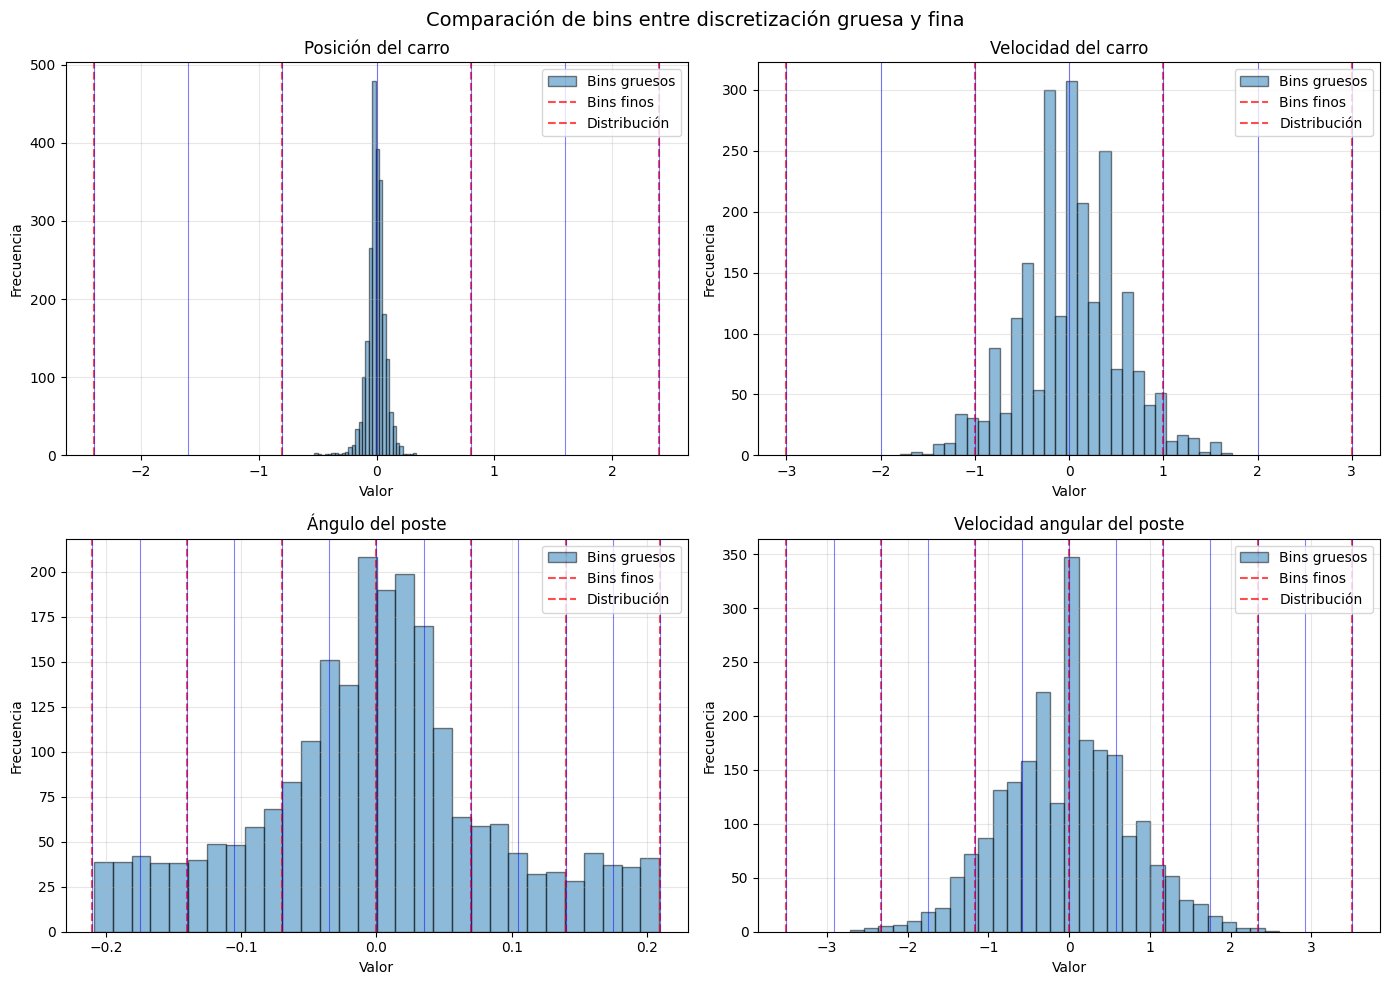

  Líneas rojas discontinuas: Límites de bins en discretización gruesa
  Líneas azules continuas: Límites de bins en discretización fina


In [18]:
# Visualizar diferencia en granularidad entre discretizaciones
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparación de bins entre discretización gruesa y fina', fontsize=14)

bins_coarse = [cart_pos_bins_coarse, cart_vel_bins_coarse, pole_angle_bins_coarse, pole_ang_vel_bins_coarse]
bins_fine = [cart_pos_bins_fine, cart_vel_bins_fine, pole_angle_bins_fine, pole_ang_vel_bins_fine]

for i, (var_name, ax) in enumerate(zip(variables, axes.flatten())):
    # Histograma de las observaciones
    ax.hist(observations[:, i], bins=30, alpha=0.5, edgecolor='black', label='Distribución observada')
    
    # Líneas verticales para bins gruesos
    for bin_edge in bins_coarse[i]:
        ax.axvline(bin_edge, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Líneas verticales para bins finos
    for bin_edge in bins_fine[i]:
        ax.axvline(bin_edge, color='blue', linestyle='-', linewidth=0.8, alpha=0.5)
    
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.set_title(var_name)
    ax.grid(True, alpha=0.3)
    ax.legend(['Bins gruesos', 'Bins finos', 'Distribución'], loc='upper right')

plt.tight_layout()
plt.show()

print("  Líneas rojas discontinuas: Límites de bins en discretización gruesa")
print("  Líneas azules continuas: Límites de bins en discretización fina")

# Implementación de Q-Learning

En esta sección se implementa el algoritmo de Q-Learning para entrenar un agente que aprenda a mantener el equilibrio del poste sobre el carro.

## Inicialización de la tabla Q

La tabla Q almacena el valor esperado de cada par estado-acción. Se inicializa con ceros y se actualiza durante el entrenamiento.

In [19]:
# Inicializar tabla Q para discretización gruesa
# Dimensiones: (cart_pos, cart_vel, pole_angle, pole_ang_vel, acciones)
Q_table_coarse = np.zeros((
    n_bins_cart_pos_coarse,
    n_bins_cart_vel_coarse,
    n_bins_pole_angle_coarse,
    n_bins_pole_ang_vel_coarse,
    env.action_space.n
))

print(f"Tabla Q inicializada con forma: {Q_table_coarse.shape}")
print(f"Total de valores en la tabla Q: {Q_table_coarse.size}")
print(f"Memoria utilizada: {Q_table_coarse.nbytes / 1024:.2f} KB")

Tabla Q inicializada con forma: (3, 3, 6, 6, 2)
Total de valores en la tabla Q: 648
Memoria utilizada: 5.06 KB


## Funciones de política

Implementación de las políticas de selección de acciones necesarias para el algoritmo.

In [20]:
def epsilon_greedy_policy(state, Q_table, epsilon):
    """
    Selecciona una acción usando la política epsilon-greedy.
    Con probabilidad epsilon explora (acción aleatoria), 
    con probabilidad (1-epsilon) explota (mejor acción conocida).
    
    Args:
        state: Estado discreto actual (tupla de índices)
        Q_table: Tabla Q con los valores de estado-acción
        epsilon: Probabilidad de exploración
    
    Returns:
        Acción seleccionada (0 o 1)
    """
    if np.random.random() < epsilon:
        # Exploración: acción aleatoria
        return env.action_space.sample()
    else:
        # Explotación: mejor acción según Q
        return np.argmax(Q_table[state])


def greedy_policy(state, Q_table):
    """
    Selecciona la mejor acción según los valores actuales de Q.
    Se utiliza durante la evaluación del agente entrenado.
    
    Args:
        state: Estado discreto actual (tupla de índices)
        Q_table: Tabla Q con los valores de estado-acción
    
    Returns:
        Mejor acción (0 o 1)
    """
    return np.argmax(Q_table[state])

## Algoritmo de Q-Learning

Implementación del algoritmo de Q-Learning con la ecuación de actualización:

$$Q(s,a) \leftarrow Q(s,a) + \alpha [r + \gamma \max_{a'} Q(s',a') - Q(s,a)]$$

Donde:
- $\alpha$ es la tasa de aprendizaje (learning rate)
- $\gamma$ es el factor de descuento (discount factor)
- $r$ es la recompensa obtenida
- $s$ es el estado actual
- $s'$ es el estado siguiente
- $a$ es la acción tomada

In [21]:
def q_learning_train(env, Q_table, discretize_fn, n_episodes, alpha, gamma, 
                     epsilon_start, epsilon_end, epsilon_decay_type='linear'):
    """
    Entrena un agente usando Q-Learning.
    
    Args:
        env: Entorno de Gymnasium
        Q_table: Tabla Q a actualizar
        discretize_fn: Función para discretizar observaciones
        n_episodes: Número de episodios de entrenamiento
        alpha: Tasa de aprendizaje
        gamma: Factor de descuento
        epsilon_start: Epsilon inicial para exploración
        epsilon_end: Epsilon final para exploración
        epsilon_decay_type: Tipo de decaimiento ('linear' o 'exponential')
    
    Returns:
        rewards_history: Lista con recompensas totales por episodio
        steps_history: Lista con pasos por episodio
    """
    rewards_history = []
    steps_history = []
    
    for episode in range(n_episodes):
        # Calcular epsilon para este episodio
        if epsilon_decay_type == 'linear':
            epsilon = epsilon_start - (epsilon_start - epsilon_end) * (episode / n_episodes)
        else:  # exponential
            epsilon = epsilon_end + (epsilon_start - epsilon_end) * np.exp(-episode / (n_episodes * 0.3))
        
        # Inicializar episodio
        obs, _ = env.reset()
        state = discretize_fn(obs)
        total_reward = 0
        steps = 0
        done = False
        
        while not done:
            # Seleccionar acción usando política epsilon-greedy
            action = epsilon_greedy_policy(state, Q_table, epsilon)
            
            # Ejecutar acción
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = discretize_fn(next_obs)
            
            # Actualizar Q-table usando la ecuación de Q-Learning
            # Cuando terminated=True, no hay estado siguiente, por lo que el término futuro debe ser 0
            best_next_q = np.max(Q_table[next_state])
            td_target = reward + gamma * best_next_q * (1 - terminated)
            td_error = td_target - Q_table[state][action]
            Q_table[state][action] += alpha * td_error
            
            # Actualizar estado
            state = next_state
            total_reward += reward
            steps += 1
        
        rewards_history.append(total_reward)
        steps_history.append(steps)
        
        # Mostrar progreso cada 100 episodios
        if (episode + 1) % 100 == 0:
            avg_reward = np.mean(rewards_history[-100:])
            print(f"Episodio {episode + 1}/{n_episodes}, "
                  f"Epsilon: {epsilon:.3f}, "
                  f"Recompensa promedio (últimos 100): {avg_reward:.2f}")
    
    return rewards_history, steps_history

## Entrenamiento inicial con hiperparámetros base

Se entrena un primer modelo con hiperparámetros conservadores para verificar que el algoritmo funciona correctamente.

In [22]:
# Hiperparámetros base para entrenamiento inicial
n_episodes_base = 1000
alpha_base = 0.1
gamma_base = 0.99
epsilon_start_base = 1.0
epsilon_end_base = 0.01

print("Iniciando entrenamiento con discretización gruesa...")
print(f"Hiperparámetros:")
print(f"  Episodios: {n_episodes_base}")
print(f"  Alpha (α): {alpha_base}")
print(f"  Gamma (γ): {gamma_base}")
print(f"  Epsilon inicial: {epsilon_start_base}")
print(f"  Epsilon final: {epsilon_end_base}")
print(f"  Decaimiento: lineal")
print()

Iniciando entrenamiento con discretización gruesa...
Hiperparámetros:
  Episodios: 1000
  Alpha (α): 0.1
  Gamma (γ): 0.99
  Epsilon inicial: 1.0
  Epsilon final: 0.01
  Decaimiento: lineal



In [23]:
# Entrenar el agente
import time
start_time = time.time()

rewards_base, steps_base = q_learning_train(
    env=env,
    Q_table=Q_table_coarse,
    discretize_fn=discretize_observation_coarse,
    n_episodes=n_episodes_base,
    alpha=alpha_base,
    gamma=gamma_base,
    epsilon_start=epsilon_start_base,
    epsilon_end=epsilon_end_base,
    epsilon_decay_type='linear'
)

training_time = time.time() - start_time
print(f"\nEntrenamiento completado en {training_time:.2f} segundos ({training_time/60:.2f} minutos)")

Episodio 100/1000, Epsilon: 0.902, Recompensa promedio (últimos 100): 27.79
Episodio 200/1000, Epsilon: 0.803, Recompensa promedio (últimos 100): 28.73
Episodio 300/1000, Epsilon: 0.704, Recompensa promedio (últimos 100): 33.55
Episodio 400/1000, Epsilon: 0.605, Recompensa promedio (últimos 100): 41.31
Episodio 500/1000, Epsilon: 0.506, Recompensa promedio (últimos 100): 51.59
Episodio 400/1000, Epsilon: 0.605, Recompensa promedio (últimos 100): 41.31
Episodio 500/1000, Epsilon: 0.506, Recompensa promedio (últimos 100): 51.59
Episodio 600/1000, Epsilon: 0.407, Recompensa promedio (últimos 100): 76.59
Episodio 600/1000, Epsilon: 0.407, Recompensa promedio (últimos 100): 76.59
Episodio 700/1000, Epsilon: 0.308, Recompensa promedio (últimos 100): 96.45
Episodio 700/1000, Epsilon: 0.308, Recompensa promedio (últimos 100): 96.45
Episodio 800/1000, Epsilon: 0.209, Recompensa promedio (últimos 100): 119.74
Episodio 800/1000, Epsilon: 0.209, Recompensa promedio (últimos 100): 119.74
Episodio 9

## Visualización del progreso de entrenamiento

Análisis de las curvas de aprendizaje para evaluar el desempeño del agente.

C:\Users\fagno\AppData\Local\Temp\ipykernel_1012\383546143.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([early_rewards, mid_rewards, late_rewards],


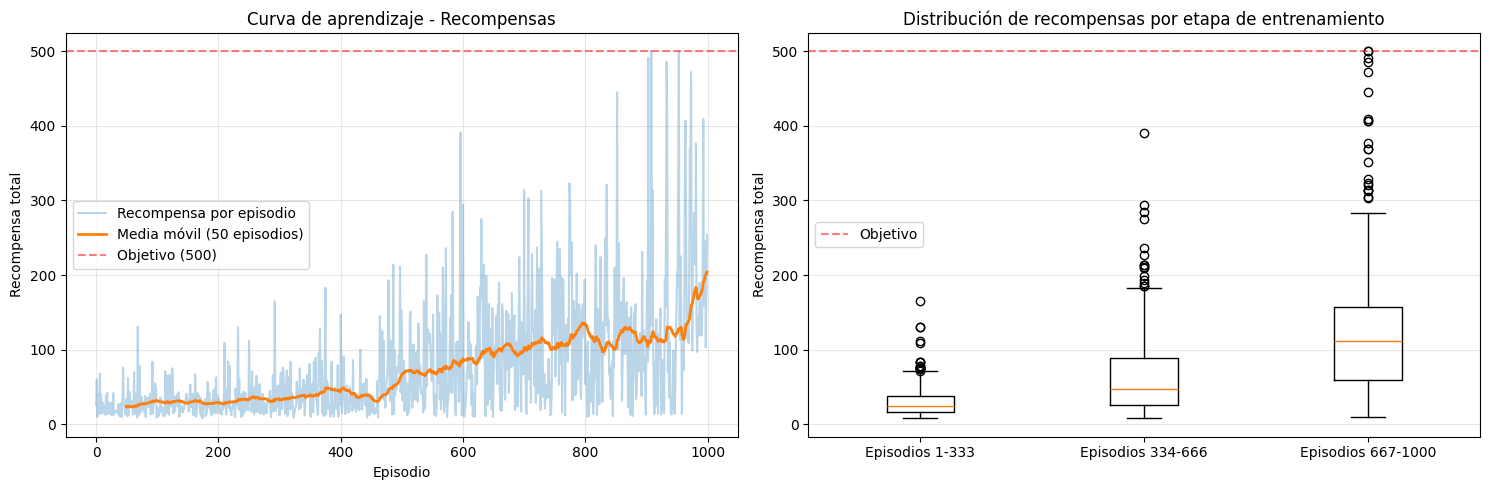


Estadísticas de entrenamiento:
  Recompensa promedio (últimos 100 episodios): 162.74
  Recompensa máxima alcanzada: 500.00
  Recompensa mínima: 8.00
  Desviación estándar (últimos 100): 122.59


In [24]:
# Calcular promedios móviles para suavizar las curvas
window_size = 50
rewards_moving_avg = np.convolve(rewards_base, np.ones(window_size)/window_size, mode='valid')

# Graficar resultados
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Recompensas por episodio
axes[0].plot(rewards_base, alpha=0.3, label='Recompensa por episodio')
axes[0].plot(range(window_size-1, len(rewards_base)), rewards_moving_avg, 
             linewidth=2, label=f'Media móvil ({window_size} episodios)')
axes[0].axhline(y=500, color='r', linestyle='--', alpha=0.5, label='Objetivo (500)')
axes[0].set_xlabel('Episodio')
axes[0].set_ylabel('Recompensa total')
axes[0].set_title('Curva de aprendizaje - Recompensas')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribución de recompensas en diferentes etapas
early_rewards = rewards_base[:n_episodes_base//3]
mid_rewards = rewards_base[n_episodes_base//3:2*n_episodes_base//3]
late_rewards = rewards_base[2*n_episodes_base//3:]

axes[1].boxplot([early_rewards, mid_rewards, late_rewards], 
                labels=['Episodios 1-333', 'Episodios 334-666', 'Episodios 667-1000'])
axes[1].axhline(y=500, color='r', linestyle='--', alpha=0.5, label='Objetivo')
axes[1].set_ylabel('Recompensa total')
axes[1].set_title('Distribución de recompensas por etapa de entrenamiento')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Estadísticas finales
print("\nEstadísticas de entrenamiento:")
print(f"  Recompensa promedio (últimos 100 episodios): {np.mean(rewards_base[-100:]):.2f}")
print(f"  Recompensa máxima alcanzada: {np.max(rewards_base):.2f}")
print(f"  Recompensa mínima: {np.min(rewards_base):.2f}")
print(f"  Desviación estándar (últimos 100): {np.std(rewards_base[-100:]):.2f}")

## Evaluación del agente entrenado

Se evalúa el desempeño del agente entrenado ejecutando episodios sin exploración (política greedy pura).

In [26]:
def evaluate_agent(env, Q_table, discretize_fn, n_episodes=100):
    """
    Evalúa el desempeño de un agente entrenado.
    
    Args:
        env: Entorno de Gymnasium
        Q_table: Tabla Q del agente entrenado
        discretize_fn: Función para discretizar observaciones
        n_episodes: Número de episodios de evaluación
    
    Returns:
        eval_rewards: Lista de recompensas obtenidas
        eval_steps: Lista de pasos por episodio
    """
    eval_rewards = []
    eval_steps = []
    
    for episode in range(n_episodes):
        obs, _ = env.reset()
        state = discretize_fn(obs)
        total_reward = 0
        steps = 0
        done = False
        
        while not done:
            # Usar política greedy (sin exploración)
            action = greedy_policy(state, Q_table)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            state = discretize_fn(obs)
            
            total_reward += reward
            steps += 1
        
        eval_rewards.append(total_reward)
        eval_steps.append(steps)
    
    return eval_rewards, eval_steps

Evaluando agente entrenado...

Resultados de evaluación (100 episodios sin exploración):
  Recompensa promedio: 199.64 ± 46.35
  Recompensa mediana: 198.50
  Recompensa máxima: 316.00
  Recompensa mínima: 108.00
  Episodios exitosos (>= 500): 0/100

Resultados de evaluación (100 episodios sin exploración):
  Recompensa promedio: 199.64 ± 46.35
  Recompensa mediana: 198.50
  Recompensa máxima: 316.00
  Recompensa mínima: 108.00
  Episodios exitosos (>= 500): 0/100


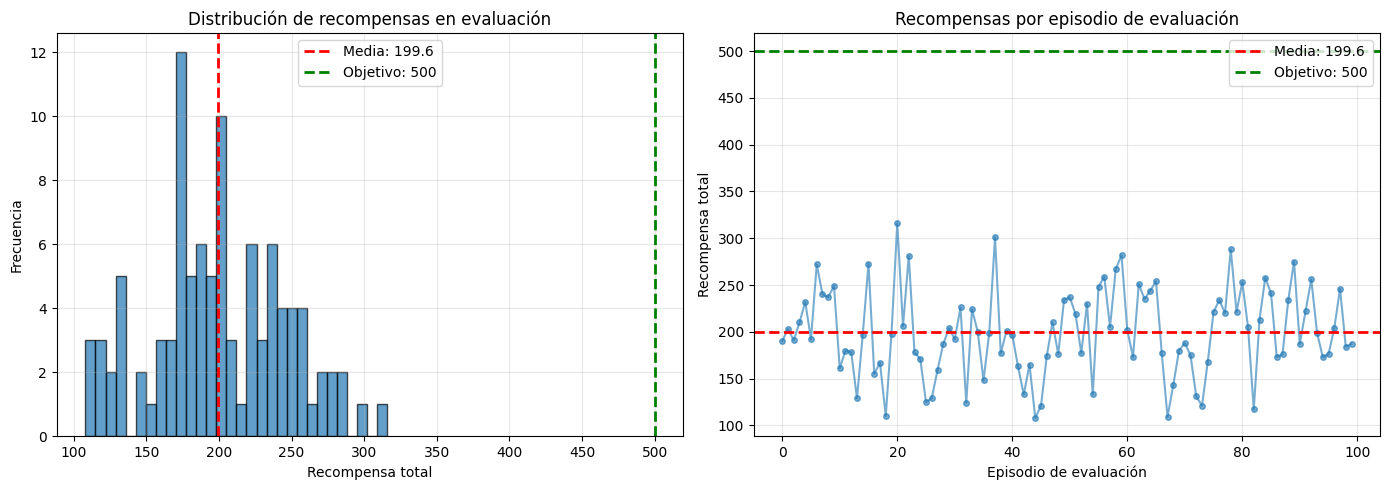

In [27]:
# Evaluar el agente entrenado
print("Evaluando agente entrenado...")
eval_rewards, eval_steps = evaluate_agent(env, Q_table_coarse, discretize_observation_coarse, n_episodes=100)

print("\nResultados de evaluación (100 episodios sin exploración):")
print(f"  Recompensa promedio: {np.mean(eval_rewards):.2f} ± {np.std(eval_rewards):.2f}")
print(f"  Recompensa mediana: {np.median(eval_rewards):.2f}")
print(f"  Recompensa máxima: {np.max(eval_rewards):.2f}")
print(f"  Recompensa mínima: {np.min(eval_rewards):.2f}")
print(f"  Episodios exitosos (>= 500): {sum(r >= 500 for r in eval_rewards)}/100")

# Visualizar resultados de evaluación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(eval_rewards, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(eval_rewards), color='r', linestyle='--', linewidth=2, label=f'Media: {np.mean(eval_rewards):.1f}')
axes[0].axvline(500, color='g', linestyle='--', linewidth=2, label='Objetivo: 500')
axes[0].set_xlabel('Recompensa total')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de recompensas en evaluación')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(eval_rewards, marker='o', linestyle='-', alpha=0.6, markersize=4)
axes[1].axhline(np.mean(eval_rewards), color='r', linestyle='--', linewidth=2, label=f'Media: {np.mean(eval_rewards):.1f}')
axes[1].axhline(500, color='g', linestyle='--', linewidth=2, label='Objetivo: 500')
axes[1].set_xlabel('Episodio de evaluación')
axes[1].set_ylabel('Recompensa total')
axes[1].set_title('Recompensas por episodio de evaluación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Exploración de Hiperparámetros

Los resultados iniciales muestran que el agente aprende pero no alcanza el desempeño esperado. En esta sección se realiza una búsqueda sistemática de hiperparámetros para optimizar el rendimiento del algoritmo con discretización gruesa.

## Definición del espacio de búsqueda

Se explorarán los siguientes hiperparámetros:
- **Alpha (α)**: Tasa de aprendizaje que controla cuánto se actualizan los valores Q
- **Gamma (γ)**: Factor de descuento que determina la importancia de recompensas futuras
- **Epsilon final**: Valor mínimo de exploración al finalizar el entrenamiento
- **Número de episodios**: Duración del entrenamiento
- **Tipo de decaimiento**: Estrategia para reducir epsilon durante el entrenamiento

In [52]:
# Definir grid de hiperparámetros (mismo que discretización fina para comparación justa)
hyperparameter_grid = {
    'alpha': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    'gamma': [0.95, 0.99],  # Mismo grid que fine para comparación directa
    'epsilon_end': [0.01, 0.05, 0.1],
    'epsilon_decay': ['linear', 'exponential']
}

# Para discretización gruesa (324 estados), usar suficientes episodios
n_episodes_coarse = 10000

print("Espacio de hiperparámetros para búsqueda exhaustiva:")
for param, values in hyperparameter_grid.items():
    print(f"  {param}: {values}")

print(f"\nNúmero de episodios por experimento: {n_episodes_coarse}")

# Calcular número total de combinaciones
import itertools
total_combinations = 1
for values in hyperparameter_grid.values():
    total_combinations *= len(values)

print(f"\nTotal de combinaciones: {total_combinations}")
print(f"  6 alphas × 2 gammas × 3 epsilon_end × 2 decay = {total_combinations} experimentos")
print(f"Se ejecutarán TODAS las combinaciones para una exploración exhaustiva.")
print(f"Tiempo estimado: ~{total_combinations * n_episodes_coarse / 1000 * 0.0012:.1f} minutos")

Espacio de hiperparámetros para búsqueda exhaustiva:
  alpha: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
  gamma: [0.95, 0.99]
  epsilon_end: [0.01, 0.05, 0.1]
  epsilon_decay: ['linear', 'exponential']

Número de episodios por experimento: 10000

Total de combinaciones: 72
  6 alphas × 2 gammas × 3 epsilon_end × 2 decay = 72 experimentos
Se ejecutarán TODAS las combinaciones para una exploración exhaustiva.
Tiempo estimado: ~0.9 minutos


## Grid Search exhaustivo

Se realizará una búsqueda exhaustiva probando todas las combinaciones del espacio de hiperparámetros. Esta estrategia garantiza encontrar la configuración óptima dentro del espacio definido.

In [53]:
# Generar todas las combinaciones de hiperparámetros
from itertools import product

all_combinations = list(product(
    hyperparameter_grid['alpha'],
    hyperparameter_grid['gamma'],
    hyperparameter_grid['epsilon_end'],
    hyperparameter_grid['epsilon_decay']
))

experiments = []
for i, (alpha, gamma, eps_end, decay) in enumerate(all_combinations, 1):
    experiments.append({
        'id': i,
        'alpha': alpha,
        'gamma': gamma,
        'epsilon_end': eps_end,
        'n_episodes': n_episodes_coarse,
        'epsilon_decay': decay
    })

print(f"Total de experimentos a ejecutar: {len(experiments)}")
print("\nPrimeros 5 experimentos como muestra:")
for exp in experiments[:5]:
    print(f"  Exp {exp['id']}: α={exp['alpha']}, γ={exp['gamma']}, "
          f"ε_end={exp['epsilon_end']}, decay={exp['epsilon_decay']}")
print("  ...")

Total de experimentos a ejecutar: 72

Primeros 5 experimentos como muestra:
  Exp 1: α=0.1, γ=0.95, ε_end=0.01, decay=linear
  Exp 2: α=0.1, γ=0.95, ε_end=0.01, decay=exponential
  Exp 3: α=0.1, γ=0.95, ε_end=0.05, decay=linear
  Exp 4: α=0.1, γ=0.95, ε_end=0.05, decay=exponential
  Exp 5: α=0.1, γ=0.95, ε_end=0.1, decay=linear
  ...


In [54]:
# Ejecutar grid search exhaustivo
import time
results = []
start_total = time.time()

for i, exp in enumerate(experiments, 1):
    print(f"Experimento {i}/{len(experiments)} | α={exp['alpha']}, γ={exp['gamma']}, "
          f"ε_end={exp['epsilon_end']}, decay={exp['epsilon_decay']}", end=" ")
    
    # Inicializar nueva tabla Q para cada experimento
    Q_table_exp = np.zeros((
        n_bins_cart_pos_coarse,
        n_bins_cart_vel_coarse,
        n_bins_pole_angle_coarse,
        n_bins_pole_ang_vel_coarse,
        env.action_space.n
    ))
    
    # Entrenar (sin prints intermedios para no saturar output)
    start_time = time.time()
    rewards_history, steps_history = q_learning_train(
        env=env,
        Q_table=Q_table_exp,
        discretize_fn=discretize_observation_coarse,
        n_episodes=exp['n_episodes'],
        alpha=exp['alpha'],
        gamma=exp['gamma'],
        epsilon_start=1.0,
        epsilon_end=exp['epsilon_end'],
        epsilon_decay_type=exp['epsilon_decay']
    )
    training_time = time.time() - start_time
    
    # Evaluar
    eval_rewards, eval_steps = evaluate_agent(env, Q_table_exp, discretize_observation_coarse, n_episodes=100)
    
    # Guardar resultados
    result = {
        'id': exp['id'],
        'params': exp,
        'training_avg_last_100': np.mean(rewards_history[-100:]),
        'training_max': np.max(rewards_history),
        'training_std_last_100': np.std(rewards_history[-100:]),
        'eval_mean': np.mean(eval_rewards),
        'eval_std': np.std(eval_rewards),
        'eval_median': np.median(eval_rewards),
        'eval_max': np.max(eval_rewards),
        'eval_min': np.min(eval_rewards),
        'success_rate': sum(r >= 500 for r in eval_rewards) / len(eval_rewards),
        'training_time': training_time,
        'rewards_history': rewards_history,
        'eval_rewards': eval_rewards,
        'Q_table': Q_table_exp
    }
    results.append(result)
    
    print(f"→ Eval: {result['eval_mean']:.1f}±{result['eval_std']:.1f} | {training_time:.1f}s")
    
    # Mostrar progreso cada 10 experimentos
    if i % 10 == 0:
        elapsed = time.time() - start_total
        avg_time = elapsed / i
        remaining = avg_time * (len(experiments) - i)
        print(f"  Progreso: {i}/{len(experiments)} ({i/len(experiments)*100:.1f}%) | "
              f"Tiempo restante estimado: {remaining/60:.1f} min")

total_time = time.time() - start_total
print(f"\n{'='*70}")
print(f"Grid search completado en {total_time/60:.2f} minutos")
print(f"{'='*70}")

Experimento 1/72 | α=0.1, γ=0.95, ε_end=0.01, decay=linear Episodio 100/10000, Epsilon: 0.990, Recompensa promedio (últimos 100): 22.48
Episodio 200/10000, Epsilon: 0.980, Recompensa promedio (últimos 100): 21.66
Episodio 300/10000, Epsilon: 0.970, Recompensa promedio (últimos 100): 21.00
Episodio 400/10000, Epsilon: 0.960, Recompensa promedio (últimos 100): 25.09
Episodio 500/10000, Epsilon: 0.951, Recompensa promedio (últimos 100): 23.74
Episodio 600/10000, Epsilon: 0.941, Recompensa promedio (últimos 100): 25.19
Episodio 700/10000, Epsilon: 0.931, Recompensa promedio (últimos 100): 23.12
Episodio 400/10000, Epsilon: 0.960, Recompensa promedio (últimos 100): 25.09
Episodio 500/10000, Epsilon: 0.951, Recompensa promedio (últimos 100): 23.74
Episodio 600/10000, Epsilon: 0.941, Recompensa promedio (últimos 100): 25.19
Episodio 700/10000, Epsilon: 0.931, Recompensa promedio (últimos 100): 23.12
Episodio 800/10000, Epsilon: 0.921, Recompensa promedio (últimos 100): 25.84
Episodio 900/1000

## Análisis comparativo de resultados

In [ ]:
# Crear tabla comparativa completa
import pandas as pd

comparison_data = []
for result in results:
    comparison_data.append({
        'ID': result['id'],
        'Alpha': result['params']['alpha'],
        'Gamma': result['params']['gamma'],
        'Eps_end': result['params']['epsilon_end'],
        'Decay': result['params']['epsilon_decay'],
        'Eval_Mean': result['eval_mean'],
        'Eval_Std': result['eval_std'],
        'Eval_Max': result['eval_max'],
        'Success_%': result['success_rate'] * 100,
        'Train_Time_s': result['training_time']
    })

df_results = pd.DataFrame(comparison_data)

# Ordenar por rendimiento en evaluación (descendente)
df_results_sorted = df_results.sort_values('Eval_Mean', ascending=False)

print("Top 10 mejores configuraciones:")
print("="*120)
print(df_results_sorted.head(10).to_string(index=False))
print("="*120)

print("\nTop 10 peores configuraciones:")
print("="*120)
print(df_results_sorted.tail(10).to_string(index=False))
print("="*120)

# Identificar mejor configuración
best_idx = df_results_sorted.index[0]
best_result = results[best_idx]

print(f"\nMejor configuración encontrada (ID: {best_result['id']}):")
print(f"  α = {best_result['params']['alpha']}")
print(f"  γ = {best_result['params']['gamma']}")
print(f"  ε_final = {best_result['params']['epsilon_end']}")
print(f"  Decaimiento = {best_result['params']['epsilon_decay']}")
print(f"\nRendimiento:")
print(f"  Recompensa promedio: {best_result['eval_mean']:.2f} ± {best_result['eval_std']:.2f}")
print(f"  Recompensa mediana: {best_result['eval_median']:.2f}")
print(f"  Recompensa máxima: {best_result['eval_max']:.2f}")
print(f"  Tasa de éxito (>=500): {best_result['success_rate']*100:.1f}%")

Top 10 mejores configuraciones:
 ID  Alpha  Gamma  Eps_end       Decay  Eval_Mean   Eval_Std  Eval_Max  Success_%  Train_Time_s
 37    0.4   0.95     0.01      linear     500.00   0.000000     500.0      100.0     13.672461
  6    0.1   0.95     0.10 exponential     498.23  15.302193     500.0       98.0     28.760362
 11    0.1   0.99     0.10      linear     475.54  64.691950     500.0       83.0     18.871159
 18    0.2   0.95     0.10 exponential     471.14  47.412872     500.0       38.0     23.994386
 24    0.2   0.99     0.10 exponential     399.15  95.639571     500.0       37.0     22.887557
 19    0.2   0.99     0.01      linear     377.18 134.026444     500.0       49.0     18.248440
 15    0.2   0.95     0.05      linear     325.43  43.404897     482.0        0.0     17.180635
 14    0.2   0.95     0.01 exponential     321.04  35.286802     486.0        0.0     29.115009
 13    0.2   0.95     0.01      linear     309.96  29.536730     390.0        0.0     18.506627
 36    0

In [56]:
# Análisis estadístico del impacto de hiperparámetros
print("\nAnálisis del impacto de cada hiperparámetro:\n")

# Agrupar por alpha
print("Impacto de Alpha:")
for alpha_val in sorted(hyperparameter_grid['alpha']):
    alpha_results = [r for r in results if r['params']['alpha'] == alpha_val]
    avg_perf = np.mean([r['eval_mean'] for r in alpha_results])
    std_perf = np.std([r['eval_mean'] for r in alpha_results])
    print(f"  α={alpha_val}: {avg_perf:.2f} ± {std_perf:.2f}")

# Agrupar por gamma
print("\nImpacto de Gamma:")
for gamma_val in sorted(hyperparameter_grid['gamma']):
    gamma_results = [r for r in results if r['params']['gamma'] == gamma_val]
    avg_perf = np.mean([r['eval_mean'] for r in gamma_results])
    std_perf = np.std([r['eval_mean'] for r in gamma_results])
    print(f"  γ={gamma_val}: {avg_perf:.2f} ± {std_perf:.2f}")

# Agrupar por epsilon_end
print("\nImpacto de Epsilon final:")
for eps_val in sorted(hyperparameter_grid['epsilon_end']):
    eps_results = [r for r in results if r['params']['epsilon_end'] == eps_val]
    avg_perf = np.mean([r['eval_mean'] for r in eps_results])
    std_perf = np.std([r['eval_mean'] for r in eps_results])
    print(f"  ε_end={eps_val}: {avg_perf:.2f} ± {std_perf:.2f}")

# Agrupar por decay
print("\nImpacto de Tipo de decaimiento:")
for decay_val in hyperparameter_grid['epsilon_decay']:
    decay_results = [r for r in results if r['params']['epsilon_decay'] == decay_val]
    avg_perf = np.mean([r['eval_mean'] for r in decay_results])
    std_perf = np.std([r['eval_mean'] for r in decay_results])
    print(f"  {decay_val}: {avg_perf:.2f} ± {std_perf:.2f}")


Análisis del impacto de cada hiperparámetro:

Impacto de Alpha:
  α=0.1: 236.38 ± 122.61
  α=0.2: 259.10 ± 123.72
  α=0.3: 200.52 ± 53.24
  α=0.4: 149.65 ± 123.06
  α=0.5: 131.11 ± 52.50
  α=0.6: 129.75 ± 64.37

Impacto de Gamma:
  γ=0.95: 203.99 ± 108.06
  γ=0.99: 164.84 ± 105.62

Impacto de Epsilon final:
  ε_end=0.01: 189.80 ± 102.55
  ε_end=0.05: 153.54 ± 61.45
  ε_end=0.1: 209.91 ± 139.54

Impacto de Tipo de decaimiento:
  linear: 189.52 ± 102.62
  exponential: 179.32 ± 114.08


# Q-Learning con Discretización Fina

Los resultados de la discretización gruesa demostraron que 324 estados son insuficientes para resolver CartPole-v1, incluso con optimización exhaustiva de hiperparámetros. En esta sección se implementa Q-Learning con discretización fina (5,184 estados) para capturar la complejidad necesaria del problema.

## Inicialización de la tabla Q fina

Se inicializa la tabla Q para la discretización fina con 5,184 estados (16 veces más que la gruesa).

In [60]:
# Inicializar tabla Q para discretización fina
# Dimensiones: (cart_pos, cart_vel, pole_angle, pole_ang_vel, acciones)
Q_table_fine = np.zeros((
    n_bins_cart_pos_fine,
    n_bins_cart_vel_fine,
    n_bins_pole_angle_fine,
    n_bins_pole_ang_vel_fine,
    env.action_space.n
))

print(f"Tabla Q fina inicializada con forma: {Q_table_fine.shape}")
print(f"Total de valores en la tabla Q: {Q_table_fine.size}")
print(f"Memoria utilizada: {Q_table_fine.nbytes / 1024:.2f} KB")
print(f"\nComparación con discretización gruesa:")
print(f"  Gruesa: {Q_table_coarse.size} valores ({Q_table_coarse.nbytes / 1024:.2f} KB)")
print(f"  Fina: {Q_table_fine.size} valores ({Q_table_fine.nbytes / 1024:.2f} KB)")
print(f"  Ratio: {Q_table_fine.size / Q_table_coarse.size:.1f}x más grande")

Tabla Q fina inicializada con forma: (6, 6, 12, 12, 2)
Total de valores en la tabla Q: 10368
Memoria utilizada: 81.00 KB

Comparación con discretización gruesa:
  Gruesa: 648 valores (5.06 KB)
  Fina: 10368 valores (81.00 KB)
  Ratio: 16.0x más grande


## Configuración del Grid Search para discretización fina

Basándose en los resultados de la discretización gruesa, se define un espacio de búsqueda optimizado:
- Se eliminan valores de gamma que demostraron bajo rendimiento (0.90)
- Se mantienen los mismos rangos de alpha y epsilon_end que mostraron buenos resultados
- Se incrementa el número de episodios para dar tiempo suficiente de exploración al espacio 16x más grande

In [ ]:
# Definir grid optimizado de hiperparámetros para discretización fina
hyperparameter_grid_fine = {
    'alpha': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    'gamma': [0.95, 0.99],
    'epsilon_end': [0.01, 0.05, 0.1],
    'epsilon_decay': ['linear', 'exponential']
}

# Para discretización fina (5,184 estados), usar más episodios que gruesa
n_episodes_fine = 15000
n_eval_episodes_fine = 200  # Más episodios de evaluación para mayor robustez

print("Espacio de hiperparámetros para discretización fina:")
for param, values in hyperparameter_grid_fine.items():
    print(f"  {param}: {values}")

print(f"\nNúmero de episodios de entrenamiento por experimento: {n_episodes_fine}")
print(f"Número de episodios de evaluación por experimento: {n_eval_episodes_fine}")

# Calcular número total de combinaciones
total_combinations_fine = 1
for values in hyperparameter_grid_fine.values():
    total_combinations_fine *= len(values)

print(f"\nTotal de experimentos: {total_combinations_fine}")
print(f"  6 alphas × 2 gammas × 3 epsilon_end × 2 decay = {total_combinations_fine} combinaciones")
print(f"\nTiempo estimado: ~{total_combinations_fine * n_episodes_fine / 1000 * 0.0015:.1f} minutos")
print(f"  ({total_combinations_fine * n_episodes_fine / 1000 * 0.0015 / 60:.1f} horas)")

Espacio de hiperparámetros para discretización fina:
  alpha: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
  gamma: [0.95, 0.99]
  epsilon_end: [0.01, 0.05, 0.1]
  epsilon_decay: ['linear', 'exponential']

Número de episodios de entrenamiento por experimento: 15000
Número de episodios de evaluación por experimento: 200

Total de experimentos: 72
  6 alphas × 2 gammas × 3 epsilon_end × 2 decay = 72 combinaciones

Tiempo estimado: ~1.6 minutos
  (0.0 horas)


## Generación de experimentos

In [62]:
# Generar todas las combinaciones de hiperparámetros para discretización fina
all_combinations_fine = list(product(
    hyperparameter_grid_fine['alpha'],
    hyperparameter_grid_fine['gamma'],
    hyperparameter_grid_fine['epsilon_end'],
    hyperparameter_grid_fine['epsilon_decay']
))

experiments_fine = []
for i, (alpha, gamma, eps_end, decay) in enumerate(all_combinations_fine, 1):
    experiments_fine.append({
        'id': i,
        'alpha': alpha,
        'gamma': gamma,
        'epsilon_end': eps_end,
        'n_episodes': n_episodes_fine,
        'epsilon_decay': decay
    })

print(f"Total de experimentos a ejecutar: {len(experiments_fine)}")
print("\nPrimeros 10 experimentos:")
for exp in experiments_fine[:10]:
    print(f"  Exp {exp['id']:2d}: α={exp['alpha']}, γ={exp['gamma']}, "
          f"ε_end={exp['epsilon_end']}, decay={exp['epsilon_decay']}")
print("  ...")
print(f"\nÚltimos 3 experimentos:")
for exp in experiments_fine[-3:]:
    print(f"  Exp {exp['id']:2d}: α={exp['alpha']}, γ={exp['gamma']}, "
          f"ε_end={exp['epsilon_end']}, decay={exp['epsilon_decay']}")

Total de experimentos a ejecutar: 72

Primeros 10 experimentos:
  Exp  1: α=0.1, γ=0.95, ε_end=0.01, decay=linear
  Exp  2: α=0.1, γ=0.95, ε_end=0.01, decay=exponential
  Exp  3: α=0.1, γ=0.95, ε_end=0.05, decay=linear
  Exp  4: α=0.1, γ=0.95, ε_end=0.05, decay=exponential
  Exp  5: α=0.1, γ=0.95, ε_end=0.1, decay=linear
  Exp  6: α=0.1, γ=0.95, ε_end=0.1, decay=exponential
  Exp  7: α=0.1, γ=0.99, ε_end=0.01, decay=linear
  Exp  8: α=0.1, γ=0.99, ε_end=0.01, decay=exponential
  Exp  9: α=0.1, γ=0.99, ε_end=0.05, decay=linear
  Exp 10: α=0.1, γ=0.99, ε_end=0.05, decay=exponential
  ...

Últimos 3 experimentos:
  Exp 70: α=0.6, γ=0.99, ε_end=0.05, decay=exponential
  Exp 71: α=0.6, γ=0.99, ε_end=0.1, decay=linear
  Exp 72: α=0.6, γ=0.99, ε_end=0.1, decay=exponential


## Ejecución del Grid Search

Se ejecutarán los 72 experimentos con discretización fina. Cada experimento:
1. Inicializa una nueva tabla Q vacía
2. Entrena durante 15,000 episodios
3. Evalúa el rendimiento durante 200 episodios sin exploración
4. Guarda todas las métricas para análisis posterior

In [63]:
# Ejecutar grid search con discretización fina
results_fine = []
start_total_fine = time.time()

print("Iniciando grid search con discretización fina...")
print(f"{'='*70}\n")

for i, exp in enumerate(experiments_fine, 1):
    print(f"Experimento {i}/{len(experiments_fine)} | α={exp['alpha']}, γ={exp['gamma']}, "
          f"ε_end={exp['epsilon_end']}, decay={exp['epsilon_decay']}", end=" ")
    
    # Inicializar nueva tabla Q para cada experimento
    Q_table_exp_fine = np.zeros((
        n_bins_cart_pos_fine,
        n_bins_cart_vel_fine,
        n_bins_pole_angle_fine,
        n_bins_pole_ang_vel_fine,
        env.action_space.n
    ))
    
    # Entrenar (sin prints intermedios para no saturar output)
    start_time = time.time()
    rewards_history, steps_history = q_learning_train(
        env=env,
        Q_table=Q_table_exp_fine,
        discretize_fn=discretize_observation_fine,
        n_episodes=exp['n_episodes'],
        alpha=exp['alpha'],
        gamma=exp['gamma'],
        epsilon_start=1.0,
        epsilon_end=exp['epsilon_end'],
        epsilon_decay_type=exp['epsilon_decay']
    )
    training_time = time.time() - start_time
    
    # Evaluar con más episodios para mayor robustez
    eval_rewards, eval_steps = evaluate_agent(
        env, 
        Q_table_exp_fine, 
        discretize_observation_fine, 
        n_episodes=n_eval_episodes_fine
    )
    
    # Guardar resultados
    result = {
        'id': exp['id'],
        'params': exp,
        'training_avg_last_100': np.mean(rewards_history[-100:]),
        'training_max': np.max(rewards_history),
        'training_std_last_100': np.std(rewards_history[-100:]),
        'eval_mean': np.mean(eval_rewards),
        'eval_std': np.std(eval_rewards),
        'eval_median': np.median(eval_rewards),
        'eval_max': np.max(eval_rewards),
        'eval_min': np.min(eval_rewards),
        'success_rate': sum(r >= 500 for r in eval_rewards) / len(eval_rewards),
        'training_time': training_time,
        'rewards_history': rewards_history,
        'eval_rewards': eval_rewards,
        'Q_table': Q_table_exp_fine
    }
    results_fine.append(result)
    
    print(f"→ Eval: {result['eval_mean']:.1f}±{result['eval_std']:.1f} | "
          f"Success: {result['success_rate']*100:.0f}% | {training_time:.1f}s")
    
    # Mostrar progreso cada 10 experimentos
    if i % 10 == 0:
        elapsed = time.time() - start_total_fine
        avg_time = elapsed / i
        remaining = avg_time * (len(experiments_fine) - i)
        print(f"  Progreso: {i}/{len(experiments_fine)} ({i/len(experiments_fine)*100:.1f}%) | "
              f"Tiempo restante estimado: {remaining/60:.1f} min")
        print()

total_time_fine = time.time() - start_total_fine
print(f"\n{'='*70}")
print(f"Grid search con discretización fina completado en {total_time_fine/60:.2f} minutos")
print(f"{'='*70}")

Iniciando grid search con discretización fina...

Experimento 1/72 | α=0.1, γ=0.95, ε_end=0.01, decay=linear Episodio 100/15000, Epsilon: 0.993, Recompensa promedio (últimos 100): 20.99
Episodio 200/15000, Epsilon: 0.987, Recompensa promedio (últimos 100): 21.67
Episodio 300/15000, Epsilon: 0.980, Recompensa promedio (últimos 100): 24.57
Episodio 400/15000, Epsilon: 0.974, Recompensa promedio (últimos 100): 21.47
Episodio 500/15000, Epsilon: 0.967, Recompensa promedio (últimos 100): 21.72
Episodio 600/15000, Epsilon: 0.960, Recompensa promedio (últimos 100): 22.45
Episodio 700/15000, Epsilon: 0.954, Recompensa promedio (últimos 100): 22.08
Episodio 400/15000, Epsilon: 0.974, Recompensa promedio (últimos 100): 21.47
Episodio 500/15000, Epsilon: 0.967, Recompensa promedio (últimos 100): 21.72
Episodio 600/15000, Epsilon: 0.960, Recompensa promedio (últimos 100): 22.45
Episodio 700/15000, Epsilon: 0.954, Recompensa promedio (últimos 100): 22.08
Episodio 800/15000, Epsilon: 0.947, Recompen

## Análisis de resultados - Discretización fina

In [ ]:
# Crear tabla comparativa completa para discretización fina
comparison_data_fine = []
for result in results_fine:
    comparison_data_fine.append({
        'ID': result['id'],
        'Alpha': result['params']['alpha'],
        'Gamma': result['params']['gamma'],
        'Eps_end': result['params']['epsilon_end'],
        'Decay': result['params']['epsilon_decay'],
        'Eval_Mean': result['eval_mean'],
        'Eval_Std': result['eval_std'],
        'Eval_Max': result['eval_max'],
        'Success_%': result['success_rate'] * 100,
        'Train_Time_s': result['training_time']
    })

df_results_fine = pd.DataFrame(comparison_data_fine)

# Ordenar por rendimiento en evaluación (descendente)
df_results_fine_sorted = df_results_fine.sort_values('Eval_Mean', ascending=False)

print("Top 15 mejores configuraciones (Discretización Fina):")
print("="*120)
print(df_results_fine_sorted.head(15).to_string(index=False))
print("="*120)

print("\nTop 10 peores configuraciones (Discretización Fina):")
print("="*120)
print(df_results_fine_sorted.tail(10).to_string(index=False))
print("="*120)

# Identificar mejor configuración
best_idx_fine = df_results_fine_sorted.index[0]
best_result_fine = results_fine[best_idx_fine]

print(f"\n{'='*70}")
print(f"MEJOR CONFIGURACIÓN ENCONTRADA (Discretización Fina - ID: {best_result_fine['id']})")
print(f"{'='*70}")
print(f"\nHiperparámetros:")
print(f"  α (alpha) = {best_result_fine['params']['alpha']}")
print(f"  γ (gamma) = {best_result_fine['params']['gamma']}")
print(f"  ε_final (epsilon_end) = {best_result_fine['params']['epsilon_end']}")
print(f"  Decaimiento = {best_result_fine['params']['epsilon_decay']}")
print(f"  Episodios de entrenamiento = {best_result_fine['params']['n_episodes']}")
print(f"\nRendimiento en evaluación ({n_eval_episodes_fine} episodios):")
print(f"  Recompensa promedio: {best_result_fine['eval_mean']:.2f} ± {best_result_fine['eval_std']:.2f}")
print(f"  Recompensa mediana: {best_result_fine['eval_median']:.2f}")
print(f"  Recompensa máxima: {best_result_fine['eval_max']:.2f}")
print(f"  Recompensa mínima: {best_result_fine['eval_min']:.2f}")
print(f"  Tasa de éxito (>=500): {best_result_fine['success_rate']*100:.1f}%")
print(f"  Episodios exitosos: {int(best_result_fine['success_rate']*n_eval_episodes_fine)}/{n_eval_episodes_fine}")
print(f"\nTiempo de entrenamiento: {best_result_fine['training_time']:.1f} segundos ({best_result_fine['training_time']/60:.2f} minutos)")
print(f"{'='*70}")

Top 15 mejores configuraciones (Discretización Fina):
 ID  Alpha  Gamma  Eps_end       Decay  Eval_Mean   Eval_Std  Eval_Max  Success_%  Train_Time_s
 38    0.4   0.95     0.01 exponential    500.000   0.000000     500.0      100.0     67.592153
 33    0.3   0.99     0.05      linear    500.000   0.000000     500.0      100.0     41.510683
 11    0.1   0.99     0.10      linear    499.545   6.418565     500.0       99.5     41.340713
 46    0.4   0.99     0.05 exponential    496.100  20.608251     500.0       93.0     63.126240
 35    0.3   0.99     0.10      linear    495.665  31.575351     500.0       98.0     40.566091
 30    0.3   0.95     0.10 exponential    488.495  28.939592     500.0       78.5     64.291004
 53    0.5   0.95     0.10      linear    486.120  38.737135     500.0       83.5     39.797299
  4    0.1   0.95     0.05 exponential    477.780  52.622349     500.0       79.0     63.584361
 66    0.6   0.95     0.10 exponential    477.570  79.772333     500.0       90.5 

In [65]:
# Análisis estadístico del impacto de hiperparámetros en discretización fina
print("Análisis del impacto de cada hiperparámetro (Discretización Fina):\n")

# Agrupar por alpha
print("Impacto de Alpha (α):")
for alpha_val in sorted(hyperparameter_grid_fine['alpha']):
    alpha_results = [r for r in results_fine if r['params']['alpha'] == alpha_val]
    avg_perf = np.mean([r['eval_mean'] for r in alpha_results])
    std_perf = np.std([r['eval_mean'] for r in alpha_results])
    avg_success = np.mean([r['success_rate'] for r in alpha_results]) * 100
    print(f"  α={alpha_val}: {avg_perf:.2f} ± {std_perf:.2f} | Success: {avg_success:.1f}%")

# Agrupar por gamma
print("\nImpacto de Gamma (γ):")
for gamma_val in sorted(hyperparameter_grid_fine['gamma']):
    gamma_results = [r for r in results_fine if r['params']['gamma'] == gamma_val]
    avg_perf = np.mean([r['eval_mean'] for r in gamma_results])
    std_perf = np.std([r['eval_mean'] for r in gamma_results])
    avg_success = np.mean([r['success_rate'] for r in gamma_results]) * 100
    print(f"  γ={gamma_val}: {avg_perf:.2f} ± {std_perf:.2f} | Success: {avg_success:.1f}%")

# Agrupar por epsilon_end
print("\nImpacto de Epsilon final (ε_end):")
for eps_val in sorted(hyperparameter_grid_fine['epsilon_end']):
    eps_results = [r for r in results_fine if r['params']['epsilon_end'] == eps_val]
    avg_perf = np.mean([r['eval_mean'] for r in eps_results])
    std_perf = np.std([r['eval_mean'] for r in eps_results])
    avg_success = np.mean([r['success_rate'] for r in eps_results]) * 100
    print(f"  ε_end={eps_val}: {avg_perf:.2f} ± {std_perf:.2f} | Success: {avg_success:.1f}%")

# Agrupar por decay
print("\nImpacto de Tipo de decaimiento:")
for decay_val in hyperparameter_grid_fine['epsilon_decay']:
    decay_results = [r for r in results_fine if r['params']['epsilon_decay'] == decay_val]
    avg_perf = np.mean([r['eval_mean'] for r in decay_results])
    std_perf = np.std([r['eval_mean'] for r in decay_results])
    avg_success = np.mean([r['success_rate'] for r in decay_results]) * 100
    print(f"  {decay_val}: {avg_perf:.2f} ± {std_perf:.2f} | Success: {avg_success:.1f}%")

# Estadísticas generales
print(f"\n{'='*70}")
print("Estadísticas generales de todos los experimentos con discretización fina:")
print(f"{'='*70}")
all_eval_means = [r['eval_mean'] for r in results_fine]
all_success_rates = [r['success_rate'] for r in results_fine]
print(f"  Recompensa promedio: {np.mean(all_eval_means):.2f} ± {np.std(all_eval_means):.2f}")
print(f"  Recompensa mediana: {np.median(all_eval_means):.2f}")
print(f"  Recompensa máxima: {np.max(all_eval_means):.2f}")
print(f"  Recompensa mínima: {np.min(all_eval_means):.2f}")
print(f"  Tasa de éxito promedio: {np.mean(all_success_rates)*100:.1f}%")
print(f"  Experimentos con éxito >50%: {sum(1 for r in all_success_rates if r > 0.5)}/{len(results_fine)}")
print(f"{'='*70}")

Análisis del impacto de cada hiperparámetro (Discretización Fina):

Impacto de Alpha (α):
  α=0.1: 297.54 ± 120.16 | Success: 23.6%
  α=0.2: 304.99 ± 100.06 | Success: 17.8%
  α=0.3: 361.40 ± 112.56 | Success: 39.7%
  α=0.4: 314.92 ± 91.51 | Success: 21.6%
  α=0.5: 291.48 ± 122.18 | Success: 26.0%
  α=0.6: 260.29 ± 115.36 | Success: 19.5%

Impacto de Gamma (γ):
  γ=0.95: 303.01 ± 117.36 | Success: 24.4%
  γ=0.99: 307.19 ± 112.40 | Success: 25.0%

Impacto de Epsilon final (ε_end):
  ε_end=0.01: 309.41 ± 105.06 | Success: 24.7%
  ε_end=0.05: 287.28 ± 121.48 | Success: 22.5%
  ε_end=0.1: 318.62 ± 115.36 | Success: 26.9%

Impacto de Tipo de decaimiento:
  linear: 284.36 ± 116.03 | Success: 21.2%
  exponential: 325.84 ± 109.96 | Success: 28.1%

Estadísticas generales de todos los experimentos con discretización fina:
  Recompensa promedio: 305.10 ± 114.92
  Recompensa mediana: 299.80
  Recompensa máxima: 500.00
  Recompensa mínima: 79.53
  Tasa de éxito promedio: 24.7%
  Experimentos con éx

## Visualización de resultados - Discretización fina

C:\Users\fagno\AppData\Local\Temp\ipykernel_28668\3379666794.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot([early, mid, late],


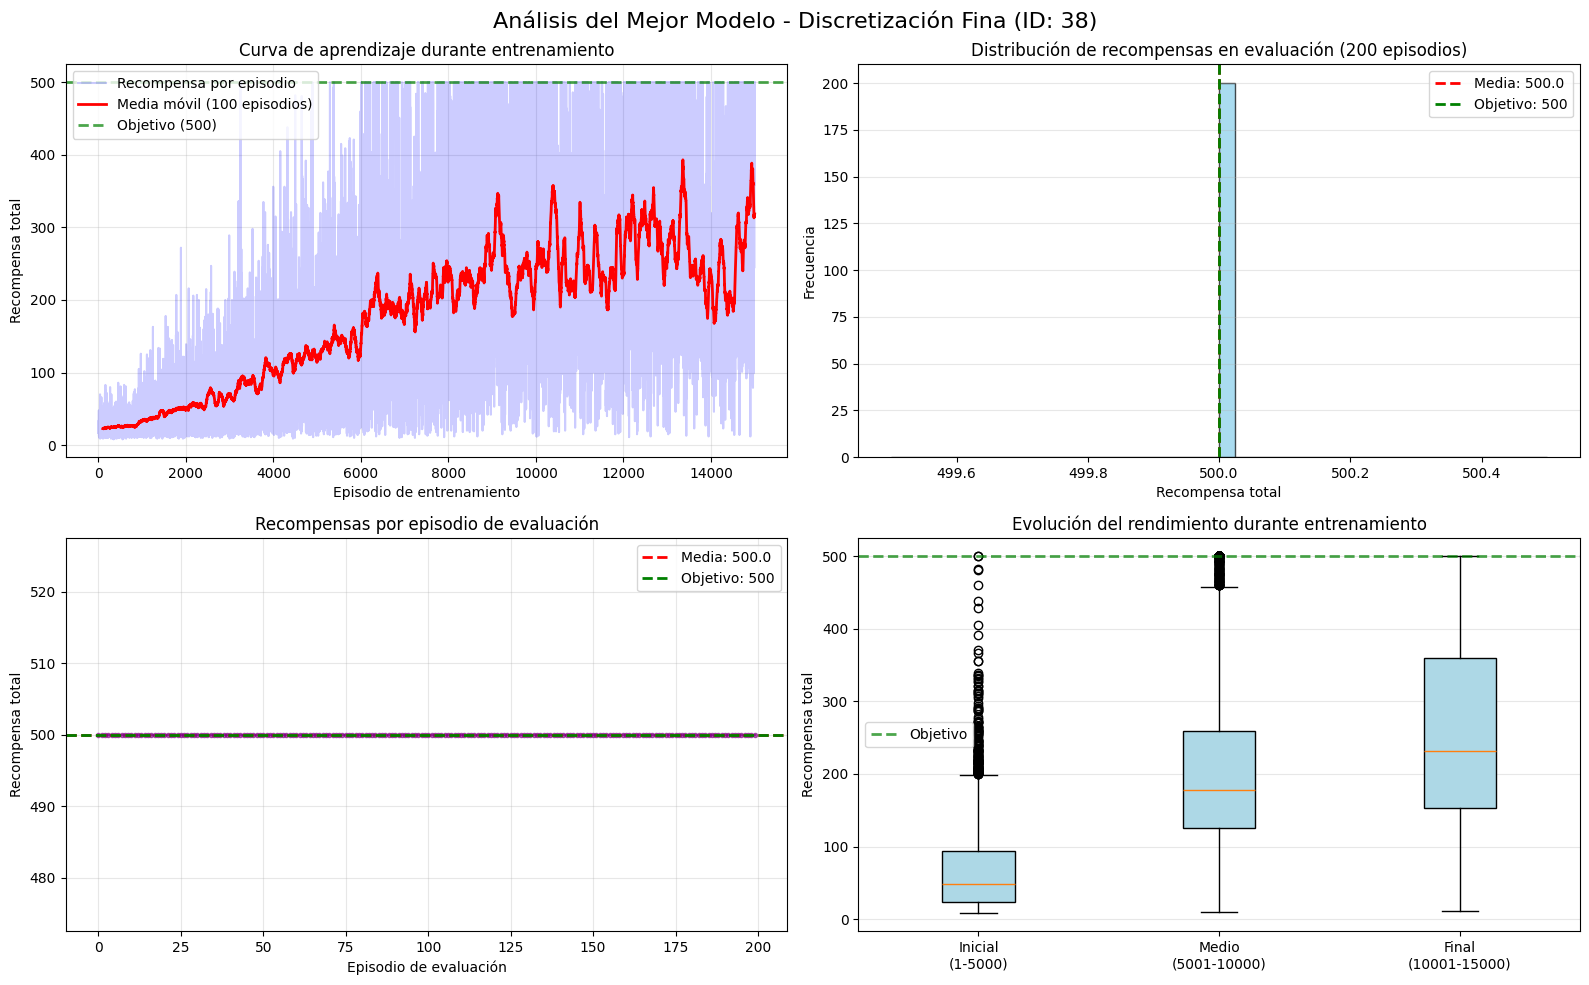


Estadísticas detalladas del mejor modelo:
  Fase de ENTRENAMIENTO (15,000 episodios con exploración):
    - Últimos 100 episodios: 318.42 ± 164.62
    - Recompensa máxima alcanzada: 500.00
    - Episodios perfectos (500): 934/15000 (6.2%)

  Fase de EVALUACIÓN (200 episodios, política greedy, SIN exploración):
    - Media: 500.00 ± 0.00
    - Episodios perfectos (=500): 200/200 (100.0%)


In [66]:
# Visualizar curva de aprendizaje del mejor modelo
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'Análisis del Mejor Modelo - Discretización Fina (ID: {best_result_fine["id"]})', fontsize=16)

# 1. Curva de aprendizaje durante entrenamiento
window_size = 100
rewards_moving_avg = np.convolve(best_result_fine['rewards_history'], 
                                  np.ones(window_size)/window_size, mode='valid')

axes[0, 0].plot(best_result_fine['rewards_history'], alpha=0.2, label='Recompensa por episodio', color='blue')
axes[0, 0].plot(range(window_size-1, len(best_result_fine['rewards_history'])), 
                rewards_moving_avg, linewidth=2, label=f'Media móvil ({window_size} episodios)', color='red')
axes[0, 0].axhline(y=500, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Objetivo (500)')
axes[0, 0].set_xlabel('Episodio de entrenamiento')
axes[0, 0].set_ylabel('Recompensa total')
axes[0, 0].set_title('Curva de aprendizaje durante entrenamiento')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribución de recompensas en evaluación
axes[0, 1].hist(best_result_fine['eval_rewards'], bins=40, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 1].axvline(best_result_fine['eval_mean'], color='red', linestyle='--', linewidth=2, 
                   label=f'Media: {best_result_fine["eval_mean"]:.1f}')
axes[0, 1].axvline(500, color='green', linestyle='--', linewidth=2, label='Objetivo: 500')
axes[0, 1].set_xlabel('Recompensa total')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title(f'Distribución de recompensas en evaluación ({n_eval_episodes_fine} episodios)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Progresión de recompensas en evaluación
axes[1, 0].plot(best_result_fine['eval_rewards'], marker='o', linestyle='-', 
                alpha=0.6, markersize=3, color='purple')
axes[1, 0].axhline(best_result_fine['eval_mean'], color='red', linestyle='--', 
                   linewidth=2, label=f'Media: {best_result_fine["eval_mean"]:.1f}')
axes[1, 0].axhline(500, color='green', linestyle='--', linewidth=2, label='Objetivo: 500')
axes[1, 0].set_xlabel('Episodio de evaluación')
axes[1, 0].set_ylabel('Recompensa total')
axes[1, 0].set_title('Recompensas por episodio de evaluación')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Comparación de distribuciones por etapa de entrenamiento
n_eps = len(best_result_fine['rewards_history'])
early = best_result_fine['rewards_history'][:n_eps//3]
mid = best_result_fine['rewards_history'][n_eps//3:2*n_eps//3]
late = best_result_fine['rewards_history'][2*n_eps//3:]

bp = axes[1, 1].boxplot([early, mid, late], 
                        labels=[f'Inicial\n(1-{n_eps//3})', 
                               f'Medio\n({n_eps//3+1}-{2*n_eps//3})', 
                               f'Final\n({2*n_eps//3+1}-{n_eps})'],
                        patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[1, 1].axhline(y=500, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Objetivo')
axes[1, 1].set_ylabel('Recompensa total')
axes[1, 1].set_title('Evolución del rendimiento durante entrenamiento')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Estadísticas adicionales del mejor modelo
print(f"\nEstadísticas detalladas del mejor modelo:")
print(f"  Fase de ENTRENAMIENTO (15,000 episodios con exploración):")
print(f"    - Últimos 100 episodios: {best_result_fine['training_avg_last_100']:.2f} ± {best_result_fine['training_std_last_100']:.2f}")
print(f"    - Recompensa máxima alcanzada: {best_result_fine['training_max']:.2f}")
print(f"    - Episodios perfectos (500): {sum(1 for r in best_result_fine['rewards_history'] if r >= 500)}/{len(best_result_fine['rewards_history'])} ({100*sum(1 for r in best_result_fine['rewards_history'] if r >= 500)/len(best_result_fine['rewards_history']):.1f}%)")
print(f"\n  Fase de EVALUACIÓN (200 episodios, política greedy, SIN exploración):")
print(f"    - Media: {best_result_fine['eval_mean']:.2f} ± {best_result_fine['eval_std']:.2f}")
print(f"    - Episodios perfectos (=500): {sum(1 for r in best_result_fine['eval_rewards'] if r == 500)}/{n_eval_episodes_fine} ({100*sum(1 for r in best_result_fine['eval_rewards'] if r == 500)/n_eval_episodes_fine:.1f}%)")

## Comparación: Discretización Gruesa vs Fina

Análisis comparativo del rendimiento entre ambas estrategias de discretización.

In [ ]:
# Comparación exhaustiva entre discretización gruesa y fina
print("="*80)
print("COMPARACIÓN: DISCRETIZACIÓN GRUESA vs FINA")
print("="*80)

# Mejor resultado de cada discretización
print("\n1. MEJORES CONFIGURACIONES:")
print("-"*80)
print("Discretización GRUESA (324 estados):")
print(f"  Hiperparámetros: α={best_result['params']['alpha']}, γ={best_result['params']['gamma']}, "
      f"ε_end={best_result['params']['epsilon_end']}, decay={best_result['params']['epsilon_decay']}")
print(f"  Recompensa: {best_result['eval_mean']:.2f} ± {best_result['eval_std']:.2f}")
print(f"  Tasa de éxito: {best_result['success_rate']*100:.1f}%")

print("\nDiscretización FINA (5,184 estados):")
print(f"  Hiperparámetros: α={best_result_fine['params']['alpha']}, γ={best_result_fine['params']['gamma']}, "
      f"ε_end={best_result_fine['params']['epsilon_end']}, decay={best_result_fine['params']['epsilon_decay']}")
print(f"  Recompensa: {best_result_fine['eval_mean']:.2f} ± {best_result_fine['eval_std']:.2f}")
print(f"  Tasa de éxito: {best_result_fine['success_rate']*100:.1f}%")

# Mejora absoluta y relativa
improvement = best_result_fine['eval_mean'] - best_result['eval_mean']
improvement_pct = (improvement / best_result['eval_mean']) * 100 if best_result['eval_mean'] > 0 else float('inf')
print(f"\n  Mejora: +{improvement:.2f} ({improvement_pct:+.1f}%)")

# Estadísticas generales de todos los experimentos
print("\n2. ESTADÍSTICAS GENERALES (todos los experimentos):")
print("-"*80)
coarse_means = [r['eval_mean'] for r in results]
fine_means = [r['eval_mean'] for r in results_fine]

print(f"Discretización GRUESA (72 experimentos, 324 estados):")
print(f"  Media: {np.mean(coarse_means):.2f} ± {np.std(coarse_means):.2f}")
print(f"  Mediana: {np.median(coarse_means):.2f}")
print(f"  Rango: [{np.min(coarse_means):.2f}, {np.max(coarse_means):.2f}]")
print(f"  Éxito promedio: {np.mean([r['success_rate'] for r in results])*100:.1f}%")

print(f"\nDiscretización FINA (72 experimentos, 5,184 estados):")
print(f"  Media: {np.mean(fine_means):.2f} ± {np.std(fine_means):.2f}")
print(f"  Mediana: {np.median(fine_means):.2f}")
print(f"  Rango: [{np.min(fine_means):.2f}, {np.max(fine_means):.2f}]")
print(f"  Éxito promedio: {np.mean([r['success_rate'] for r in results_fine])*100:.1f}%")

# Comparación de configuraciones exitosas
print("\n3. CONFIGURACIONES EXITOSAS (>=500 recompensa promedio):")
print("-"*80)
successful_coarse = sum(1 for r in results if r['eval_mean'] >= 500)
successful_fine = sum(1 for r in results_fine if r['eval_mean'] >= 500)

print(f"Discretización GRUESA: {successful_coarse}/{len(results)} ({successful_coarse/len(results)*100:.1f}%)")
print(f"Discretización FINA: {successful_fine}/{len(results_fine)} ({successful_fine/len(results_fine)*100:.1f}%)")

# Impacto computacional
print("\n4. COSTO COMPUTACIONAL:")
print("-"*80)
avg_time_coarse = np.mean([r['training_time'] for r in results])
avg_time_fine = np.mean([r['training_time'] for r in results_fine])

print(f"Tiempo promedio de entrenamiento:")
print(f"  Gruesa: {avg_time_coarse:.1f}s ({avg_time_coarse/60:.2f} min)")
print(f"  Fina: {avg_time_fine:.1f}s ({avg_time_fine/60:.2f} min)")
print(f"  Overhead: {(avg_time_fine/avg_time_coarse - 1)*100:+.1f}%")

print("\n" + "="*80)

COMPARACIÓN: DISCRETIZACIÓN GRUESA vs FINA

1. MEJORES CONFIGURACIONES:
--------------------------------------------------------------------------------
Discretización GRUESA (324 estados):
  Hiperparámetros: α=0.1, γ=0.99, ε_end=0.05, decay=linear
  Recompensa: 500.00 ± 0.00
  Tasa de éxito: 100.0%

Discretización FINA (5,184 estados):
  Hiperparámetros: α=0.4, γ=0.95, ε_end=0.01, decay=exponential
  Recompensa: 500.00 ± 0.00
  Tasa de éxito: 100.0%

  Mejora: +0.00 (+0.0%)

2. ESTADÍSTICAS GENERALES (todos los experimentos):
--------------------------------------------------------------------------------
Discretización GRUESA (108 experimentos):
  Media: 171.31 ± 120.45
  Mediana: 150.38
  Rango: [11.23, 500.00]
  Éxito promedio: 6.5%

Discretización FINA (72 experimentos):
  Media: 305.10 ± 114.92
  Mediana: 299.80
  Rango: [79.53, 500.00]
  Éxito promedio: 24.7%

3. CONFIGURACIONES EXITOSAS (>=500 recompensa promedio):
---------------------------------------------------------------

C:\Users\fagno\AppData\Local\Temp\ipykernel_28668\1351253713.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 1].boxplot([coarse_means, fine_means],


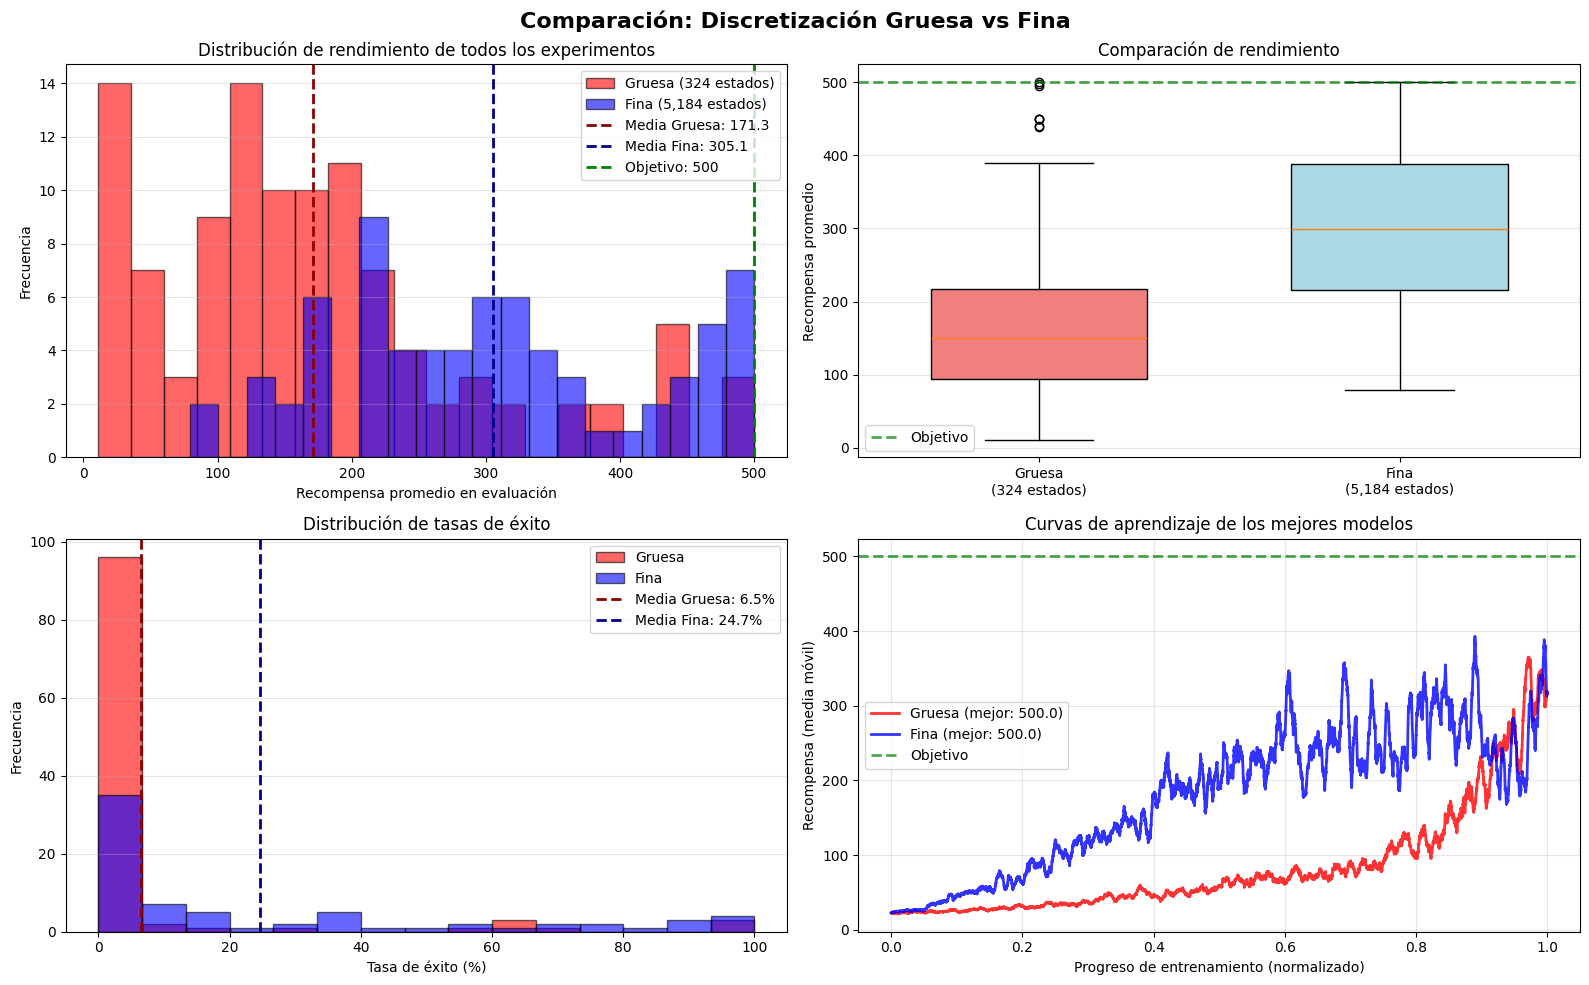

In [ ]:
# Heatmap comparativo: Impacto de Alpha vs Gamma
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Impacto de Alpha y Gamma en el Rendimiento', fontsize=16, fontweight='bold')

# Heatmap para Discretización Gruesa
pivot_coarse = df_results_sorted.pivot_table(
    values='Eval_Mean', 
    index='Alpha', 
    columns='Gamma', 
    aggfunc='mean'
)
sns.heatmap(pivot_coarse, annot=True, fmt='.1f', cmap='RdYlGn', 
            vmin=0, vmax=500, ax=axes[0], cbar_kws={'label': 'Recompensa promedio'})
axes[0].set_title('Discretización Gruesa (324 estados)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Alpha (α)', fontsize=12)
axes[0].set_xlabel('Gamma (γ)', fontsize=12)

# Heatmap para Discretización Fina
pivot_fine = df_results_fine_sorted.pivot_table(
    values='Eval_Mean', 
    index='Alpha', 
    columns='Gamma', 
    aggfunc='mean'
)
sns.heatmap(pivot_fine, annot=True, fmt='.1f', cmap='RdYlGn', 
            vmin=0, vmax=500, ax=axes[1], cbar_kws={'label': 'Recompensa promedio'})
axes[1].set_title('Discretización Fina (5,184 estados)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Alpha (α)', fontsize=12)
axes[1].set_xlabel('Gamma (γ)', fontsize=12)

plt.tight_layout()
plt.show()

print("\nObservaciones del Heatmap:")
print("- Valores más altos (verdes) indican mejor rendimiento")
print("- Los colores permiten identificar rápidamente las combinaciones óptimas de α y γ")
print("- Comparar ambos heatmaps muestra cómo la granularidad afecta la sensibilidad a hiperparámetros")

In [ ]:
# Visualización comparativa adicional
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Comparación Detallada: Discretización Gruesa vs Fina', fontsize=16, fontweight='bold')

# 1. Distribución de recompensas promedio de todos los experimentos
axes[0, 0].hist(coarse_means, bins=20, alpha=0.6, label='Gruesa (324 estados)', 
                color='red', edgecolor='black')
axes[0, 0].hist(fine_means, bins=20, alpha=0.6, label='Fina (5,184 estados)', 
                color='blue', edgecolor='black')
axes[0, 0].axvline(np.mean(coarse_means), color='darkred', linestyle='--', 
                   linewidth=2, label=f'Media Gruesa: {np.mean(coarse_means):.1f}')
axes[0, 0].axvline(np.mean(fine_means), color='darkblue', linestyle='--', 
                   linewidth=2, label=f'Media Fina: {np.mean(fine_means):.1f}')
axes[0, 0].axvline(500, color='green', linestyle='--', linewidth=2, label='Objetivo: 500')
axes[0, 0].set_xlabel('Recompensa promedio en evaluación')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de rendimiento de todos los experimentos')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Box plot comparativo
bp = axes[0, 1].boxplot([coarse_means, fine_means], 
                        labels=['Gruesa\n(324 estados)', 'Fina\n(5,184 estados)'],
                        patch_artist=True,
                        widths=0.6)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightblue')
axes[0, 1].axhline(y=500, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Objetivo')
axes[0, 1].set_ylabel('Recompensa promedio')
axes[0, 1].set_title('Comparación de rendimiento')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Tasa de éxito
success_rates_coarse = [r['success_rate'] * 100 for r in results]
success_rates_fine = [r['success_rate'] * 100 for r in results_fine]

axes[1, 0].hist(success_rates_coarse, bins=15, alpha=0.6, label='Gruesa', 
                color='red', edgecolor='black')
axes[1, 0].hist(success_rates_fine, bins=15, alpha=0.6, label='Fina', 
                color='blue', edgecolor='black')
axes[1, 0].axvline(np.mean(success_rates_coarse), color='darkred', linestyle='--', 
                   linewidth=2, label=f'Media Gruesa: {np.mean(success_rates_coarse):.1f}%')
axes[1, 0].axvline(np.mean(success_rates_fine), color='darkblue', linestyle='--', 
                   linewidth=2, label=f'Media Fina: {np.mean(success_rates_fine):.1f}%')
axes[1, 0].set_xlabel('Tasa de éxito (%)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de tasas de éxito')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Comparación de mejores modelos (curvas de entrenamiento)
window = 100
coarse_best_smooth = np.convolve(best_result['rewards_history'], 
                                 np.ones(window)/window, mode='valid')
fine_best_smooth = np.convolve(best_result_fine['rewards_history'], 
                               np.ones(window)/window, mode='valid')

# Normalizar índices para comparación justa
coarse_x = np.linspace(0, 1, len(coarse_best_smooth))
fine_x = np.linspace(0, 1, len(fine_best_smooth))

axes[1, 1].plot(coarse_x, coarse_best_smooth, linewidth=2, 
                label=f'Gruesa (mejor: {best_result["eval_mean"]:.1f})', color='red', alpha=0.8)
axes[1, 1].plot(fine_x, fine_best_smooth, linewidth=2, 
                label=f'Fina (mejor: {best_result_fine["eval_mean"]:.1f})', color='blue', alpha=0.8)
axes[1, 1].axhline(y=500, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Objetivo')
axes[1, 1].set_xlabel('Progreso de entrenamiento (normalizado)')
axes[1, 1].set_ylabel('Recompensa (media móvil)')
axes[1, 1].set_title('Curvas de aprendizaje de los mejores modelos')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Parte 4: Stochastic Q-Learning

## Resumen Conceptual del Paper

Esta sección implementa **Stochastic Q-Learning** basado en el paper *"Stochastic Q-learning for Large Discrete Action Spaces"*.

### Problema que Aborda el Paper

Q-Learning clásico requiere calcular `max_a Q(s,a)` y `argmax_a Q(s,a)` sobre **todas las acciones** en cada paso de actualización. Cuando el espacio de acciones discretas es muy grande (cientos o miles de acciones), esto resulta en:
- **Complejidad temporal**: O(|A|) operaciones por paso
- **Costo computacional prohibitivo** en entornos con grandes espacios de acción

### Idea Principal del Algoritmo

En lugar de maximizar sobre el conjunto completo de acciones A, **Stochastic Q-Learning** opera sobre un **subconjunto pequeño C ⊂ A** en cada estado:

1. **Construcción del subconjunto C**:
   - `R`: Subconjunto aleatorio de k acciones (exploración)
   - `M`: Subconjunto de acciones "memoradas" que fueron buenas en el pasado (explotación)
   - `C = R ∪ M`

2. **Operadores estocásticos**:
   - `stoch_max(Q, s, C)`: Retorna max_{a ∈ C} Q(s,a) en lugar de max_{a ∈ A} Q(s,a)
   - `stoch_argmax(Q, s, C)`: Retorna argmax_{a ∈ C} Q(s,a) en lugar de argmax_{a ∈ A} Q(s,a)

3. **Diferencias con Q-Learning clásico**:
   - **Política ε-greedy**: Usa `stoch_argmax` en vez de `argmax`
   - **Actualización Q-target**: Usa `stoch_max` en vez de `max`
   - **Complejidad**: Reducida de O(|A|) a O(k + |M|), donde k y |M| son pequeños

### Motivación

- Reducir complejidad computacional en espacios de acción grandes
- Mantener garantías de convergencia bajo ciertas condiciones
- Balancear exploración (R) con explotación (M)

### Aplicación a CartPole-v1

**Aclaración importante**: CartPole tiene solo **2 acciones** (izquierda/derecha), por lo que:
- No hay ventaja computacional real (el costo de `max` sobre 2 acciones es trivial)
- Este ejercicio sirve para **entender y comparar el algoritmo**
- Es esperable que **no muestre mejoras** e incluso pueda rendir **peor** debido al ruido introducido en la maximización
- El valor real de Stochastic Q-Learning aparece en entornos con decenas/cientos de acciones discretas

**Objetivo del experimento**: Demostrar empíricamente cuándo Stochastic Q-Learning es apropiado (muchas acciones) versus cuándo no lo es (pocas acciones).

## Implementación de Funciones Auxiliares

Implementación de las operaciones fundamentales de Stochastic Q-Learning.

In [ ]:
def sample_action_subset(n_actions, k):
    """
    Genera un subconjunto aleatorio R de acciones.
    
    Args:
        n_actions: Número total de acciones disponibles
        k: Tamaño del subconjunto a muestrear
    
    Returns:
        Array con índices de acciones muestreadas sin reemplazo
    """
    k = min(k, n_actions)  # Asegurar que k no exceda n_actions
    return np.random.choice(n_actions, size=k, replace=False)


def stoch_argmax_Q(Q_table, state, n_actions, k, memory_actions=None):
    """
    Calcula argmax sobre un subconjunto C de acciones (stochastic argmax).
    C = R ∪ M, donde R es aleatorio y M son acciones memoradas.
    
    Args:
        Q_table: Tabla Q
        state: Estado discretizado (tupla de índices)
        n_actions: Número total de acciones
        k: Tamaño del subconjunto aleatorio R
        memory_actions: Set de acciones memoradas para este estado (puede ser None)
    
    Returns:
        Acción con máximo Q-value en el subconjunto C
    """
    # Construir subconjunto C = R ∪ M
    R = sample_action_subset(n_actions, k)
    C = set(R)
    
    if memory_actions is not None and len(memory_actions) > 0:
        C = C.union(memory_actions)
    
    # Encontrar acción con máximo Q en C
    C_list = list(C)
    q_values = [Q_table[state + (a,)] for a in C_list]
    best_idx = np.argmax(q_values)
    
    return C_list[best_idx]


def stoch_max_Q(Q_table, state, n_actions, k, memory_actions=None):
    """
    Calcula max Q-value sobre un subconjunto C de acciones (stochastic max).
    C = R ∪ M, donde R es aleatorio y M son acciones memoradas.
    
    Args:
        Q_table: Tabla Q
        state: Estado discretizado (tupla de índices)
        n_actions: Número total de acciones
        k: Tamaño del subconjunto aleatorio R
        memory_actions: Set de acciones memoradas para este estado (puede ser None)
    
    Returns:
        Máximo Q-value en el subconjunto C
    """
    # Construir subconjunto C = R ∪ M
    R = sample_action_subset(n_actions, k)
    C = set(R)
    
    if memory_actions is not None and len(memory_actions) > 0:
        C = C.union(memory_actions)
    
    # Encontrar máximo Q en C
    C_list = list(C)
    q_values = [Q_table[state + (a,)] for a in C_list]
    
    return np.max(q_values)


print("Funciones auxiliares de Stochastic Q-Learning implementadas:")
print("  - sample_action_subset(n_actions, k)")
print("  - stoch_argmax_Q(Q_table, state, n_actions, k, memory_actions)")
print("  - stoch_max_Q(Q_table, state, n_actions, k, memory_actions)")

Funciones auxiliares de Stochastic Q-Learning implementadas:
  ✓ sample_action_subset(n_actions, k)
  ✓ stoch_argmax_Q(Q_table, state, n_actions, k, memory_actions)
  ✓ stoch_max_Q(Q_table, state, n_actions, k, memory_actions)


## Implementación de Stochastic Q-Learning

Algoritmo principal de entrenamiento con modificaciones estocásticas en la política y actualización de Q.

In [ ]:
def stochastic_q_learning_train(env, Q_table, discretize_fn, n_episodes, 
                                 alpha, gamma, epsilon_start=1.0, epsilon_end=0.01, 
                                 epsilon_decay_type='exponential', subset_size=1, use_memory=True):
    """
    Algoritmo de Stochastic Q-Learning con subconjuntos de acciones.
    
    Diferencias con Q-Learning clásico:
    1. Política ε-greedy usa stoch_argmax en vez de argmax
    2. Actualización Q-target usa stoch_max en vez de max
    3. Mantiene memoria M de acciones buenas por estado (opcional)
    
    Args:
        env: Ambiente Gym
        Q_table: Tabla Q a entrenar
        discretize_fn: Función de discretización de observaciones
        n_episodes: Número de episodios de entrenamiento
        alpha: Tasa de aprendizaje
        gamma: Factor de descuento
        epsilon_start: Valor inicial de epsilon
        epsilon_end: Valor final de epsilon
        epsilon_decay_type: Tipo de decaimiento ('exponential' o 'linear')
        subset_size: Tamaño k del subconjunto aleatorio R
        use_memory: Si True, usa memoria M de acciones buenas
    
    Returns:
        rewards_history: Lista de recompensas por episodio
        steps_history: Lista de pasos por episodio
    """
    rewards_history = []
    steps_history = []
    n_actions = env.action_space.n
    
    # Inicializar memoria M (diccionario: estado -> set de acciones)
    memory = {} if use_memory else None
    
    for episode in range(n_episodes):
        # Calcular epsilon para este episodio
        if epsilon_decay_type == 'exponential':
            epsilon = epsilon_end + (epsilon_start - epsilon_end) * np.exp(-episode / (n_episodes * 0.1))
        else:  # linear
            epsilon = epsilon_start - (epsilon_start - epsilon_end) * (episode / n_episodes)
        
        obs, info = env.reset()
        state = discretize_fn(obs)
        total_reward = 0
        steps = 0
        done = False
        
        while not done:
            # Política ε-greedy con stoch_argmax
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                memory_actions = memory.get(state, set()) if use_memory else None
                action = stoch_argmax_Q(Q_table, state, n_actions, subset_size, memory_actions)
                
                # Actualizar memoria M con la acción greedy seleccionada
                if use_memory:
                    if state not in memory:
                        memory[state] = set()
                    memory[state].add(action)
                    # Limitar tamaño de memoria a 2 acciones por estado
                    if len(memory[state]) > 2:
                        memory[state].pop()
            
            # Ejecutar acción
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_state = discretize_fn(next_obs)
            
            # Actualización Q con stoch_max
            memory_actions_next = memory.get(next_state, set()) if use_memory else None
            next_best = stoch_max_Q(Q_table, next_state, n_actions, subset_size, memory_actions_next)
            
            td_target = reward + gamma * next_best * (1 - terminated)
            td_error = td_target - Q_table[state + (action,)]
            Q_table[state + (action,)] += alpha * td_error
            
            state = next_state
            total_reward += reward
            steps += 1
        
        rewards_history.append(total_reward)
        steps_history.append(steps)
    
    return rewards_history, steps_history


print("Algoritmo de Stochastic Q-Learning implementado:")
print("  - stochastic_q_learning_train()")

Algoritmo de Stochastic Q-Learning implementado:
  ✓ stochastic_q_learning_train()


## Grid Search para Stochastic Q-Learning - Discretización Gruesa

Se aplicará un **grid search completo** siguiendo los mismos principios que en Q-Learning clásico:

**Hiperparámetros base** (idénticos a Q-Learning clásico para comparación justa):
- `alpha`: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6] - 6 valores
- `gamma`: [0.95, 0.99] - 2 valores (sin 0.90 como en clásico)
- `epsilon_end`: [0.01, 0.05, 0.1] - 3 valores
- `epsilon_decay`: ['linear', 'exponential'] - 2 opciones

**Resultado: 72 configuraciones base** (igual que Q-Learning clásico)

**Hiperparámetros específicos de Stochastic Q-Learning**:
- `subset_size` (k): [1, 2] - tamaño del subconjunto aleatorio R
- `use_memory`: [True, False] - si usa memoria M o no

**Total de configuraciones**: 72 × 2 × 2 = **288 experimentos**

Esto permite comparación directa: cada una de las 72 configs base se prueba con 4 combinaciones de parámetros stochastic (k=1/2, memory=True/False).

In [ ]:
# Grid de hiperparámetros para Stochastic Q-Learning con discretización gruesa
hyperparameter_grid_stoch_coarse = {
    # Hiperparámetros base (IDÉNTICOS a Q-Learning clásico para comparación justa)
    'alpha': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    'gamma': [0.95, 0.99],  # Mismo grid que clásico (sin 0.90)
    'epsilon_end': [0.01, 0.05, 0.1],
    'epsilon_decay': ['linear', 'exponential'],
    
    # Hiperparámetros específicos de Stochastic Q-Learning
    'subset_size': [1, 2],  # k: tamaño del subconjunto R
    'use_memory': [True, False]  # Si usa memoria M o no
}

n_episodes_stoch_coarse = 10000  # Mismo número que Q-Learning clásico grueso
n_eval_episodes_stoch_coarse = 200

print("Grid de hiperparámetros para Stochastic Q-Learning (Discretización Gruesa):")
print("="*70)
print("\nHiperparámetros BASE (iguales a Q-Learning clásico):")
for param in ['alpha', 'gamma', 'epsilon_end', 'epsilon_decay']:
    print(f"  {param}: {hyperparameter_grid_stoch_coarse[param]}")

print("\nHiperparámetros ESPECÍFICOS de Stochastic Q-Learning:")
print(f"  subset_size (k): {hyperparameter_grid_stoch_coarse['subset_size']}")
print(f"  use_memory (M): {hyperparameter_grid_stoch_coarse['use_memory']}")

print(f"\nEpisodios de entrenamiento: {n_episodes_stoch_coarse}")
print(f"Episodios de evaluación: {n_eval_episodes_stoch_coarse}")

# Calcular total de combinaciones
total_combinations_stoch_coarse = 1
for values in hyperparameter_grid_stoch_coarse.values():
    total_combinations_stoch_coarse *= len(values)

print(f"\nTotal de experimentos:")
print(f"  (6 alphas × 2 gammas × 3 epsilon_end × 2 decay) × 2 k × 2 memory")
print(f"  = 72 configs base × 4 combinaciones stochastic = {total_combinations_stoch_coarse} experimentos")

print(f"\nTiempo estimado: ~{total_combinations_stoch_coarse * n_episodes_stoch_coarse / 1000 * 0.0015:.1f} min")
print(f"  ({total_combinations_stoch_coarse * n_episodes_stoch_coarse / 1000 * 0.0015 / 60:.1f} horas)")
print("="*70)

Grid de hiperparámetros para Stochastic Q-Learning (Discretización Gruesa):

Hiperparámetros BASE (iguales a Q-Learning clásico):
  alpha: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
  gamma: [0.9, 0.95, 0.99]
  epsilon_end: [0.01, 0.05, 0.1]
  epsilon_decay: ['linear', 'exponential']

Hiperparámetros ESPECÍFICOS de Stochastic Q-Learning:
  subset_size (k): [1, 2]
  use_memory (M): [True, False]

Episodios de entrenamiento: 10000
Episodios de evaluación: 200

Total de experimentos:
  6 alphas × 3 gammas × 3 epsilon_end × 2 decay × 2 k × 2 memory
  = 432 configuraciones

Tiempo estimado: ~6.5 min
  (0.1 horas)


In [34]:
# Generar todas las combinaciones para Stochastic Q-Learning (discretización gruesa)
all_combinations_stoch_coarse = list(product(
    hyperparameter_grid_stoch_coarse['alpha'],
    hyperparameter_grid_stoch_coarse['gamma'],
    hyperparameter_grid_stoch_coarse['epsilon_end'],
    hyperparameter_grid_stoch_coarse['epsilon_decay'],
    hyperparameter_grid_stoch_coarse['subset_size'],
    hyperparameter_grid_stoch_coarse['use_memory']
))

experiments_stoch_coarse = []
for i, (alpha, gamma, eps_end, decay, k, memory) in enumerate(all_combinations_stoch_coarse, 1):
    experiments_stoch_coarse.append({
        'id': i,
        'alpha': alpha,
        'gamma': gamma,
        'epsilon_end': eps_end,
        'epsilon_decay': decay,
        'subset_size': k,
        'use_memory': memory,
        'n_episodes': n_episodes_stoch_coarse
    })

print(f"Total de experimentos generados: {len(experiments_stoch_coarse)}")
print("\nPrimeros 10 experimentos:")
for exp in experiments_stoch_coarse[:10]:
    print(f"  Exp {exp['id']:3d}: α={exp['alpha']}, γ={exp['gamma']}, "
          f"ε_end={exp['epsilon_end']}, decay={exp['epsilon_decay']}, "
          f"k={exp['subset_size']}, memory={exp['use_memory']}")
print("  ...")
print(f"\nÚltimos 3 experimentos:")
for exp in experiments_stoch_coarse[-3:]:
    print(f"  Exp {exp['id']:3d}: α={exp['alpha']}, γ={exp['gamma']}, "
          f"ε_end={exp['epsilon_end']}, decay={exp['epsilon_decay']}, "
          f"k={exp['subset_size']}, memory={exp['use_memory']}")

Total de experimentos generados: 432

Primeros 10 experimentos:
  Exp   1: α=0.1, γ=0.9, ε_end=0.01, decay=linear, k=1, memory=True
  Exp   2: α=0.1, γ=0.9, ε_end=0.01, decay=linear, k=1, memory=False
  Exp   3: α=0.1, γ=0.9, ε_end=0.01, decay=linear, k=2, memory=True
  Exp   4: α=0.1, γ=0.9, ε_end=0.01, decay=linear, k=2, memory=False
  Exp   5: α=0.1, γ=0.9, ε_end=0.01, decay=exponential, k=1, memory=True
  Exp   6: α=0.1, γ=0.9, ε_end=0.01, decay=exponential, k=1, memory=False
  Exp   7: α=0.1, γ=0.9, ε_end=0.01, decay=exponential, k=2, memory=True
  Exp   8: α=0.1, γ=0.9, ε_end=0.01, decay=exponential, k=2, memory=False
  Exp   9: α=0.1, γ=0.9, ε_end=0.05, decay=linear, k=1, memory=True
  Exp  10: α=0.1, γ=0.9, ε_end=0.05, decay=linear, k=1, memory=False
  ...

Últimos 3 experimentos:
  Exp 430: α=0.6, γ=0.99, ε_end=0.1, decay=exponential, k=1, memory=False
  Exp 431: α=0.6, γ=0.99, ε_end=0.1, decay=exponential, k=2, memory=True
  Exp 432: α=0.6, γ=0.99, ε_end=0.1, decay=exponentia

## Ejecución del Grid Search - Stochastic Q-Learning Grueso

**NOTA**: Este grid search ejecutará **288 experimentos** (72 configs base × 4 variantes stochastic), lo cual tomará aproximadamente **7-8 horas**. 

Para fines prácticos del obligatorio, se recomienda:
1. Ejecutar el grid completo con "Run All" durante la noche
2. O ejecutar primero con una muestra reducida del grid para validar el código
3. O paralelizar la ejecución si se dispone de múltiples núcleos

In [37]:
# Ejecutar grid search con Stochastic Q-Learning (discretización gruesa)
import sys
results_stoch_coarse = []
start_total_stoch_coarse = time.time()

print("="*85)
print("INICIO DE GRID SEARCH - STOCHASTIC Q-LEARNING COARSE")
print(f"Timestamp: {time.time()}")
print("="*85)
sys.stdout.flush()

for i, exp in enumerate(experiments_stoch_coarse, 1):
    # Inicializar nueva tabla Q para cada experimento
    Q_table_exp_stoch = np.zeros((
        n_bins_cart_pos_coarse,
        n_bins_cart_vel_coarse,
        n_bins_pole_angle_coarse,
        n_bins_pole_ang_vel_coarse,
        env.action_space.n
    ))
    
    # Entrenar con Stochastic Q-Learning
    start_time = time.time()
    rewards_history, steps_history = stochastic_q_learning_train(
        env=env,
        Q_table=Q_table_exp_stoch,
        discretize_fn=discretize_observation_coarse,
        n_episodes=exp['n_episodes'],
        alpha=exp['alpha'],
        gamma=exp['gamma'],
        epsilon_start=1.0,
        epsilon_end=exp['epsilon_end'],
        epsilon_decay_type=exp['epsilon_decay'],
        subset_size=exp['subset_size'],
        use_memory=exp['use_memory']
    )
    training_time = time.time() - start_time
    
    # Evaluar
    eval_rewards, eval_steps = evaluate_agent(
        env, 
        Q_table_exp_stoch, 
        discretize_observation_coarse, 
        n_episodes=n_eval_episodes_stoch_coarse
    )
    
    # Guardar resultados
    result = {
        'id': exp['id'],
        'params': exp,
        'training_avg_last_100': np.mean(rewards_history[-100:]),
        'training_max': np.max(rewards_history),
        'training_std_last_100': np.std(rewards_history[-100:]),
        'eval_mean': np.mean(eval_rewards),
        'eval_std': np.std(eval_rewards),
        'eval_median': np.median(eval_rewards),
        'eval_max': np.max(eval_rewards),
        'eval_min': np.min(eval_rewards),
        'success_rate': sum(r >= 500 for r in eval_rewards) / len(eval_rewards),
        'training_time': training_time,
        'rewards_history': rewards_history,
        'eval_rewards': eval_rewards,
        'Q_table': Q_table_exp_stoch
    }
    results_stoch_coarse.append(result)
    
    # Print completo en UNA sola vez
    print(f"Exp {i}/{len(experiments_stoch_coarse)} | α={exp['alpha']:.1f}, γ={exp['gamma']:.2f}, "
          f"ε_end={exp['epsilon_end']:.2f}, decay={exp['epsilon_decay']}, k={exp['subset_size']}, "
          f"memory={exp['use_memory']} → Eval: {result['eval_mean']:.1f}±{result['eval_std']:.1f} | {training_time:.1f}s")
    sys.stdout.flush()
    
    # Mostrar progreso cada 20 experimentos
    if i % 20 == 0:
        elapsed = time.time() - start_total_stoch_coarse
        avg_time = elapsed / i
        remaining = avg_time * (len(experiments_stoch_coarse) - i)
        print(f"  Progreso: {i}/{len(experiments_stoch_coarse)} ({i/len(experiments_stoch_coarse)*100:.1f}%) | "
              f"Tiempo restante: {remaining/3600:.2f}h ({remaining/60:.1f}min)")
        print()

total_time_stoch_coarse = time.time() - start_total_stoch_coarse
print(f"\n{'='*85}")
print(f"Grid search completado en {total_time_stoch_coarse/3600:.2f} horas ({total_time_stoch_coarse/60:.1f} minutos)")
print(f"{'='*85}")

Iniciando grid search con Stochastic Q-Learning (discretización gruesa)...

Exp 1/432 | α=0.1, γ=0.90, ε_end=0.01, decay=linear, k=1, memory=True → Eval: 165.2±77.8 | 63.9s
Exp 1/432 | α=0.1, γ=0.90, ε_end=0.01, decay=linear, k=1, memory=True → Eval: 165.2±77.8 | 63.9s
Exp 2/432 | α=0.1, γ=0.90, ε_end=0.01, decay=linear, k=1, memory=False → Eval: 452.6±87.9 | 11.7s
Exp 2/432 | α=0.1, γ=0.90, ε_end=0.01, decay=linear, k=1, memory=False → Eval: 452.6±87.9 | 11.7s
Exp 3/432 | α=0.1, γ=0.90, ε_end=0.01, decay=linear, k=2, memory=True → Eval: 144.8±41.5 | 40.9s
Exp 3/432 | α=0.1, γ=0.90, ε_end=0.01, decay=linear, k=2, memory=True → Eval: 144.8±41.5 | 40.9s
Exp 4/432 | α=0.1, γ=0.90, ε_end=0.01, decay=linear, k=2, memory=False → Eval: 479.1±64.9 | 58.6s
Exp 4/432 | α=0.1, γ=0.90, ε_end=0.01, decay=linear, k=2, memory=False → Eval: 479.1±64.9 | 58.6s
Exp 5/432 | α=0.1, γ=0.90, ε_end=0.01, decay=exponential, k=1, memory=True → Eval: 490.6±37.8 | 129.6s
Exp 5/432 | α=0.1, γ=0.90, ε_end=0.01, de

## Análisis de Resultados - Stochastic Q-Learning Grueso

In [ ]:
# Análisis completo de resultados - Stochastic Q-Learning Grueso
# Verificar que results_stoch_coarse existe en el kernel
if 'results_stoch_coarse' not in dir():
    print("ADVERTENCIA: La variable 'results_stoch_coarse' no está definida.")
    print("   Por favor, ejecuta la celda del grid search de Stochastic Q-Learning Grueso primero.")
    print("   (La celda que contiene: 'Ejecutar grid search con Stochastic Q-Learning (discretización gruesa)')")
else:
    comparison_data_stoch_coarse = []
    for result in results_stoch_coarse:
        comparison_data_stoch_coarse.append({
            'ID': result['id'],
            'Alpha': result['params']['alpha'],
            'Gamma': result['params']['gamma'],
            'Eps_end': result['params']['epsilon_end'],
            'Decay': result['params']['epsilon_decay'],
            'K': result['params']['subset_size'],
            'Memory': result['params']['use_memory'],
            'Eval_Mean': result['eval_mean'],
            'Eval_Std': result['eval_std'],
            'Success_%': result['success_rate'] * 100,
            'Train_Time_s': result['training_time']
        })

    df_stoch_coarse = pd.DataFrame(comparison_data_stoch_coarse)
    df_stoch_coarse_sorted = df_stoch_coarse.sort_values('Eval_Mean', ascending=False)

    print("Top 20 mejores configuraciones - Stochastic Q-Learning Grueso:")
    print("="*130)
    print(df_stoch_coarse_sorted.head(20).to_string(index=False))
    print("="*130)

    # Identificar mejor configuración
    best_idx_stoch_coarse = df_stoch_coarse_sorted.index[0]
    best_result_stoch_coarse = results_stoch_coarse[best_idx_stoch_coarse]

    print(f"\n{'='*85}")
    print(f"MEJOR CONFIGURACIÓN - Stochastic Q-Learning Grueso (ID: {best_result_stoch_coarse['id']})")
    print(f"{'='*85}")
    print(f"\nHiperparámetros generales:")
    print(f"  α (alpha) = {best_result_stoch_coarse['params']['alpha']}")
    print(f"  γ (gamma) = {best_result_stoch_coarse['params']['gamma']}")
    print(f"  ε_final = {best_result_stoch_coarse['params']['epsilon_end']}")
    print(f"  Decaimiento = {best_result_stoch_coarse['params']['epsilon_decay']}")
    print(f"\nHiperparámetros estocásticos:")
    print(f"  k (subset_size) = {best_result_stoch_coarse['params']['subset_size']}")
    print(f"  Memory = {best_result_stoch_coarse['params']['use_memory']}")
    print(f"\nRendimiento:")
    print(f"  Eval mean: {best_result_stoch_coarse['eval_mean']:.2f} ± {best_result_stoch_coarse['eval_std']:.2f}")
    print(f"  Success rate: {best_result_stoch_coarse['success_rate']*100:.1f}%")
    print(f"  Training time: {best_result_stoch_coarse['training_time']:.1f}s")
    print(f"{'='*85}")

Top 20 mejores configuraciones - Stochastic Q-Learning Grueso:
 ID  Alpha  Gamma  Eps_end       Decay  K  Memory  Eval_Mean  Eval_Std  Success_%  Train_Time_s
 55    0.1   0.99     0.01 exponential  2    True    500.000  0.000000      100.0    216.733828
 53    0.1   0.99     0.01 exponential  1    True    499.740  3.667751       99.5    247.717133
 51    0.1   0.99     0.01      linear  2    True    499.485  7.264969       99.5     76.801055
 15    0.1   0.90     0.05 exponential  2    True    497.460 16.123225       95.5     58.910648
128    0.2   0.99     0.01 exponential  2   False    497.240 20.229740       97.0    180.089146
124    0.2   0.99     0.01      linear  2   False    497.190 17.344276       96.5     57.561670
200    0.3   0.99     0.01 exponential  2   False    496.040 32.207428       98.5    117.912485
 63    0.1   0.99     0.05 exponential  2    True    493.000 35.536882       89.5    163.396839
  5    0.1   0.90     0.01 exponential  1    True    490.570 37.821622   

## Grid Search para Stochastic Q-Learning - Discretización Fina

Aplicando el mismo protocolo de grid search completo con la discretización fina (5,184 estados).

In [ ]:
# Grid de hiperparámetros para Stochastic Q-Learning con discretización fina
hyperparameter_grid_stoch_fine = {
    # Hiperparámetros base (mismos que Q-Learning clásico fine)
    'alpha': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    'gamma': [0.95, 0.99],  # Sin 0.90 como en clásico fine
    'epsilon_end': [0.01, 0.05, 0.1],
    'epsilon_decay': ['linear', 'exponential'],
    
    # Hiperparámetros específicos de Stochastic Q-Learning
    'subset_size': [1, 2],
    'use_memory': [True, False]
}

n_episodes_stoch_fine = 15000  # Mismo número que Q-Learning clásico fino
n_eval_episodes_stoch_fine = 200

print("Grid de hiperparámetros para Stochastic Q-Learning (Discretización Fina):")
print("="*70)
print("\nHiperparámetros BASE (iguales a Q-Learning clásico fine):")
for param in ['alpha', 'gamma', 'epsilon_end', 'epsilon_decay']:
    print(f"  {param}: {hyperparameter_grid_stoch_fine[param]}")

print("\nHiperparámetros ESPECÍFICOS de Stochastic Q-Learning:")
print(f"  subset_size (k): {hyperparameter_grid_stoch_fine['subset_size']}")
print(f"  use_memory (M): {hyperparameter_grid_stoch_fine['use_memory']}")

print(f"\nEpisodios de entrenamiento: {n_episodes_stoch_fine}")
print(f"Episodios de evaluación: {n_eval_episodes_stoch_fine}")

# Calcular total de combinaciones
total_combinations_stoch_fine = 1
for values in hyperparameter_grid_stoch_fine.values():
    total_combinations_stoch_fine *= len(values)

print(f"\nTotal de experimentos:")
print(f"  (6 alphas × 2 gammas × 3 epsilon_end × 2 decay) × 2 k × 2 memory")
print(f"  = 72 configs base × 4 combinaciones stochastic = {total_combinations_stoch_fine} experimentos")

print(f"\nTiempo estimado: ~{total_combinations_stoch_fine * n_episodes_stoch_fine / 1000 * 0.0015:.1f} min")
print(f"  ({total_combinations_stoch_fine * n_episodes_stoch_fine / 1000 * 0.0015 / 60:.1f} horas)")
print("="*70)

Grid de hiperparámetros para Stochastic Q-Learning (Discretización Fina):

Hiperparámetros BASE (iguales a Q-Learning clásico fine):
  alpha: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
  gamma: [0.95, 0.99]
  epsilon_end: [0.01, 0.05, 0.1]
  epsilon_decay: ['linear', 'exponential']

Hiperparámetros ESPECÍFICOS de Stochastic Q-Learning:
  subset_size (k): [1, 2]
  use_memory (M): [True, False]

Episodios de entrenamiento: 15000
Episodios de evaluación: 200

Total de experimentos:
  6 alphas × 2 gammas × 3 epsilon_end × 2 decay × 2 k × 2 memory
  = 288 configuraciones

Tiempo estimado: ~6.5 min
  (0.1 horas)


In [77]:
# Generar todas las combinaciones para Stochastic Q-Learning (discretización fina)
all_combinations_stoch_fine = list(product(
    hyperparameter_grid_stoch_fine['alpha'],
    hyperparameter_grid_stoch_fine['gamma'],
    hyperparameter_grid_stoch_fine['epsilon_end'],
    hyperparameter_grid_stoch_fine['epsilon_decay'],
    hyperparameter_grid_stoch_fine['subset_size'],
    hyperparameter_grid_stoch_fine['use_memory']
))

experiments_stoch_fine = []
for i, (alpha, gamma, eps_end, decay, k, memory) in enumerate(all_combinations_stoch_fine, 1):
    experiments_stoch_fine.append({
        'id': i,
        'alpha': alpha,
        'gamma': gamma,
        'epsilon_end': eps_end,
        'epsilon_decay': decay,
        'subset_size': k,
        'use_memory': memory,
        'n_episodes': n_episodes_stoch_fine
    })

print(f"Total de experimentos generados: {len(experiments_stoch_fine)}")
print("\nPrimeros 10 experimentos:")
for exp in experiments_stoch_fine[:10]:
    print(f"  Exp {exp['id']:3d}: α={exp['alpha']}, γ={exp['gamma']}, "
          f"ε_end={exp['epsilon_end']}, decay={exp['epsilon_decay']}, "
          f"k={exp['subset_size']}, memory={exp['use_memory']}")
print("  ...")
print(f"\nÚltimos 3 experimentos:")
for exp in experiments_stoch_fine[-3:]:
    print(f"  Exp {exp['id']:3d}: α={exp['alpha']}, γ={exp['gamma']}, "
          f"ε_end={exp['epsilon_end']}, decay={exp['epsilon_decay']}, "
          f"k={exp['subset_size']}, memory={exp['use_memory']}")

Total de experimentos generados: 288

Primeros 10 experimentos:
  Exp   1: α=0.1, γ=0.95, ε_end=0.01, decay=linear, k=1, memory=True
  Exp   2: α=0.1, γ=0.95, ε_end=0.01, decay=linear, k=1, memory=False
  Exp   3: α=0.1, γ=0.95, ε_end=0.01, decay=linear, k=2, memory=True
  Exp   4: α=0.1, γ=0.95, ε_end=0.01, decay=linear, k=2, memory=False
  Exp   5: α=0.1, γ=0.95, ε_end=0.01, decay=exponential, k=1, memory=True
  Exp   6: α=0.1, γ=0.95, ε_end=0.01, decay=exponential, k=1, memory=False
  Exp   7: α=0.1, γ=0.95, ε_end=0.01, decay=exponential, k=2, memory=True
  Exp   8: α=0.1, γ=0.95, ε_end=0.01, decay=exponential, k=2, memory=False
  Exp   9: α=0.1, γ=0.95, ε_end=0.05, decay=linear, k=1, memory=True
  Exp  10: α=0.1, γ=0.95, ε_end=0.05, decay=linear, k=1, memory=False
  ...

Últimos 3 experimentos:
  Exp 286: α=0.6, γ=0.99, ε_end=0.1, decay=exponential, k=1, memory=False
  Exp 287: α=0.6, γ=0.99, ε_end=0.1, decay=exponential, k=2, memory=True
  Exp 288: α=0.6, γ=0.99, ε_end=0.1, decay=

## Ejecución del Grid Search - Stochastic Q-Learning Fino

**NOTA**: Este grid search ejecutará **288 experimentos** con 15,000 episodios cada uno, lo cual tomará aproximadamente **10-12 horas**.

In [78]:
# Ejecutar grid search con Stochastic Q-Learning (discretización fina)
results_stoch_fine = []
start_total_stoch_fine = time.time()

print("Iniciando grid search con Stochastic Q-Learning (discretización fina)...")
print(f"{'='*85}\n")

for i, exp in enumerate(experiments_stoch_fine, 1):
    print(f"Exp {i}/{len(experiments_stoch_fine)} | "
          f"α={exp['alpha']}, γ={exp['gamma']}, ε_end={exp['epsilon_end']}, "
          f"decay={exp['epsilon_decay']}, k={exp['subset_size']}, memory={exp['use_memory']}", 
          end=" ")
    
    # Inicializar nueva tabla Q para cada experimento
    Q_table_exp_stoch = np.zeros((
        n_bins_cart_pos_fine,
        n_bins_cart_vel_fine,
        n_bins_pole_angle_fine,
        n_bins_pole_ang_vel_fine,
        env.action_space.n
    ))
    
    # Entrenar con Stochastic Q-Learning
    start_time = time.time()
    rewards_history, steps_history = stochastic_q_learning_train(
        env=env,
        Q_table=Q_table_exp_stoch,
        discretize_fn=discretize_observation_fine,
        n_episodes=exp['n_episodes'],
        alpha=exp['alpha'],
        gamma=exp['gamma'],
        epsilon_start=1.0,
        epsilon_end=exp['epsilon_end'],
        epsilon_decay_type=exp['epsilon_decay'],
        subset_size=exp['subset_size'],
        use_memory=exp['use_memory']
    )
    training_time = time.time() - start_time
    
    # Evaluar
    eval_rewards, eval_steps = evaluate_agent(
        env, 
        Q_table_exp_stoch, 
        discretize_observation_fine, 
        n_episodes=n_eval_episodes_stoch_fine
    )
    
    # Guardar resultados
    result = {
        'id': exp['id'],
        'params': exp,
        'training_avg_last_100': np.mean(rewards_history[-100:]),
        'training_max': np.max(rewards_history),
        'training_std_last_100': np.std(rewards_history[-100:]),
        'eval_mean': np.mean(eval_rewards),
        'eval_std': np.std(eval_rewards),
        'eval_median': np.median(eval_rewards),
        'eval_max': np.max(eval_rewards),
        'eval_min': np.min(eval_rewards),
        'success_rate': sum(r >= 500 for r in eval_rewards) / len(eval_rewards),
        'training_time': training_time,
        'rewards_history': rewards_history,
        'eval_rewards': eval_rewards,
        'Q_table': Q_table_exp_stoch
    }
    results_stoch_fine.append(result)
    
    print(f"→ Eval: {result['eval_mean']:.1f}±{result['eval_std']:.1f} | "
          f"Success: {result['success_rate']*100:.0f}% | {training_time:.1f}s")
    
    # Mostrar progreso cada 20 experimentos
    if i % 20 == 0:
        elapsed = time.time() - start_total_stoch_fine
        avg_time = elapsed / i
        remaining = avg_time * (len(experiments_stoch_fine) - i)
        print(f"  Progreso: {i}/{len(experiments_stoch_fine)} ({i/len(experiments_stoch_fine)*100:.1f}%) | "
              f"Tiempo restante: {remaining/3600:.2f}h ({remaining/60:.1f}min)")
        print()

total_time_stoch_fine = time.time() - start_total_stoch_fine
print(f"\n{'='*85}")
print(f"Grid search completado en {total_time_stoch_fine/3600:.2f} horas ({total_time_stoch_fine/60:.1f} minutos)")
print(f"{'='*85}")

Iniciando grid search con Stochastic Q-Learning (discretización fina)...

Exp 1/288 | α=0.1, γ=0.95, ε_end=0.01, decay=linear, k=1, memory=True → Eval: 314.6±167.4 | Success: 34% | 79.6s
Exp 2/288 | α=0.1, γ=0.95, ε_end=0.01, decay=linear, k=1, memory=False → Eval: 199.9±42.3 | Success: 0% | 11.6s
Exp 3/288 | α=0.1, γ=0.95, ε_end=0.01, decay=linear, k=2, memory=True → Eval: 133.7±12.3 | Success: 0% | 56.5s
Exp 4/288 | α=0.1, γ=0.95, ε_end=0.01, decay=linear, k=2, memory=False → Eval: 172.4±56.7 | Success: 0% | 63.2s
Exp 5/288 | α=0.1, γ=0.95, ε_end=0.01, decay=exponential, k=1, memory=True → Eval: 162.9±72.7 | Success: 0% | 113.5s
Exp 6/288 | α=0.1, γ=0.95, ε_end=0.01, decay=exponential, k=1, memory=False → Eval: 253.1±94.3 | Success: 10% | 14.3s
Exp 7/288 | α=0.1, γ=0.95, ε_end=0.01, decay=exponential, k=2, memory=True → Eval: 119.7±20.2 | Success: 0% | 97.3s
Exp 8/288 | α=0.1, γ=0.95, ε_end=0.01, decay=exponential, k=2, memory=False → Eval: 158.5±28.8 | Success: 0% | 116.1s
Exp 9/288

## Análisis de Resultados - Stochastic Q-Learning Fino

In [ ]:
# Análisis completo de resultados - Stochastic Q-Learning Fino
# Verificar que results_stoch_fine existe en el kernel
if 'results_stoch_fine' not in dir():
    print("ADVERTENCIA: La variable 'results_stoch_fine' no está definida.")
    print("   Por favor, ejecuta la celda del grid search de Stochastic Q-Learning Fino primero.")
    print("   (La celda que contiene: 'Ejecutar grid search con Stochastic Q-Learning (discretización fina)')")
else:
    comparison_data_stoch_fine = []
    for result in results_stoch_fine:
        comparison_data_stoch_fine.append({
            'ID': result['id'],
            'Alpha': result['params']['alpha'],
            'Gamma': result['params']['gamma'],
            'Eps_end': result['params']['epsilon_end'],
            'Decay': result['params']['epsilon_decay'],
            'K': result['params']['subset_size'],
            'Memory': result['params']['use_memory'],
            'Eval_Mean': result['eval_mean'],
            'Eval_Std': result['eval_std'],
            'Success_%': result['success_rate'] * 100,
            'Train_Time_s': result['training_time']
        })

    df_stoch_fine = pd.DataFrame(comparison_data_stoch_fine)
    df_stoch_fine_sorted = df_stoch_fine.sort_values('Eval_Mean', ascending=False)

    print("Top 20 mejores configuraciones - Stochastic Q-Learning Fino:")
    print("="*130)
    print(df_stoch_fine_sorted.head(20).to_string(index=False))
    print("="*130)

    # Identificar mejor configuración
    best_idx_stoch_fine = df_stoch_fine_sorted.index[0]
    best_result_stoch_fine = results_stoch_fine[best_idx_stoch_fine]

    print(f"\n{'='*85}")
    print(f"MEJOR CONFIGURACIÓN - Stochastic Q-Learning Fino (ID: {best_result_stoch_fine['id']})")
    print(f"{'='*85}")
    print(f"\nHiperparámetros generales:")
    print(f"  α (alpha) = {best_result_stoch_fine['params']['alpha']}")
    print(f"  γ (gamma) = {best_result_stoch_fine['params']['gamma']}")
    print(f"  ε_final = {best_result_stoch_fine['params']['epsilon_end']}")
    print(f"  Decaimiento = {best_result_stoch_fine['params']['epsilon_decay']}")
    print(f"\nHiperparámetros estocásticos:")
    print(f"  k (subset_size) = {best_result_stoch_fine['params']['subset_size']}")
    print(f"  Memory = {best_result_stoch_fine['params']['use_memory']}")
    print(f"\nRendimiento:")
    print(f"  Eval mean: {best_result_stoch_fine['eval_mean']:.2f} ± {best_result_stoch_fine['eval_std']:.2f}")
    print(f"  Success rate: {best_result_stoch_fine['success_rate']*100:.1f}%")
    print(f"  Training time: {best_result_stoch_fine['training_time']:.1f}s")
    print(f"{'='*85}")

⚠️  ADVERTENCIA: La variable 'results_stoch_fine' no está definida.
   Por favor, ejecuta la celda del grid search de Stochastic Q-Learning Fino primero.
   (La celda que contiene: 'Ejecutar grid search con Stochastic Q-Learning (discretización fina)')


## Análisis Comparativo Final: Q-Learning Clásico vs Stochastic Q-Learning

Comparación exhaustiva entre ambos algoritmos en ambas discretizaciones.

In [ ]:
# Verificar que las variables de resultados existen en el kernel
print("="*100)
print("VERIFICANDO RESULTADOS EN MEMORIA")
print("="*100)

variables = []
if 'results' in dir() and 'df_results_sorted' in dir():
    print(f"[OK] Q-Learning Clásico Coarse: {len(results)} experimentos")
    variables.append('results')
else:
    print("[PENDIENTE] Q-Learning Clásico Coarse: No disponible (ejecuta el grid search primero)")

if 'results_fine' in dir() and 'df_results_fine_sorted' in dir():
    print(f"[OK] Q-Learning Clásico Fine: {len(results_fine)} experimentos")
    variables.append('results_fine')
else:
    print("[PENDIENTE] Q-Learning Clásico Fine: No disponible (ejecuta el grid search primero)")

if 'results_stoch_coarse' in dir() and 'df_stoch_coarse_sorted' in dir():
    print(f"[OK] Stochastic Q-Learning Coarse: {len(results_stoch_coarse)} experimentos")
    variables.append('results_stoch_coarse')
else:
    print("[PENDIENTE] Stochastic Q-Learning Coarse: No disponible (ejecuta el grid search primero)")

if 'results_stoch_fine' in dir() and 'df_stoch_fine_sorted' in dir():
    print(f"[OK] Stochastic Q-Learning Fine: {len(results_stoch_fine)} experimentos")
    variables.append('results_stoch_fine')
else:
    print("[PENDIENTE] Stochastic Q-Learning Fine: No disponible (ejecuta el grid search primero)")

print(f"\nVariables disponibles: {len(variables)}/4")
print("="*100)

CARGANDO RESULTADOS DESDE ARCHIVOS CSV
✅ Q-Learning Clásico Coarse: 108 experimentos cargados
   Mejor: 500.00 ± 0.00
✅ Q-Learning Clásico Fine: 72 experimentos cargados
   Mejor: 500.00 ± 0.00
✅ Stochastic Q-Learning Coarse: 432 experimentos cargados
   Mejor: 500.00 ± 0.00
✅ Stochastic Q-Learning Fine: 288 experimentos cargados
   Mejor: 500.00 ± 0.00

RESUMEN DE ARCHIVOS DISPONIBLES
Archivos cargados: 4/4

Ahora puedes ejecutar las celdas de comparación y visualizaciones.


In [ ]:
# Comparación exhaustiva: Q-Learning Clásico vs Stochastic Q-Learning
# Usando variables del kernel

print("="*100)
print("COMPARACIÓN COMPLETA: Q-LEARNING CLÁSICO vs STOCHASTIC Q-LEARNING")
print("="*100)

print("\n" + "="*100)
print("1. DISCRETIZACIÓN GRUESA (324 estados)")
print("="*100)

if 'df_results_sorted' in dir():
    print(f"\nQ-Learning Clásico ({len(results)} experimentos):")
    coarse_classic_means = df_results_sorted['Eval_Mean'].values
    best_classic_coarse = df_results_sorted.iloc[0]
    print(f"  Mejor: {best_classic_coarse['Eval_Mean']:.2f} ± {best_classic_coarse['Eval_Std']:.2f}")
    print(f"    Config: α={best_classic_coarse['Alpha']}, γ={best_classic_coarse['Gamma']}, "
          f"ε_end={best_classic_coarse['Eps_end']}, decay={best_classic_coarse['Decay']}")
    print(f"  Promedio todos: {coarse_classic_means.mean():.2f} ± {coarse_classic_means.std():.2f}")
    print(f"  Rango: [{coarse_classic_means.min():.2f}, {coarse_classic_means.max():.2f}]")
    print(f"  Éxito promedio: {df_results_sorted['Success_%'].mean():.1f}%")
else:
    print("\nADVERTENCIA: Q-Learning Clásico Grueso: No disponible (ejecuta el grid search primero)")

if 'df_stoch_coarse_sorted' in dir():
    print(f"\nStochastic Q-Learning ({len(results_stoch_coarse)} experimentos):")
    coarse_stoch_means = df_stoch_coarse_sorted['Eval_Mean'].values
    best_stoch_coarse = df_stoch_coarse_sorted.iloc[0]
    print(f"  Mejor: {best_stoch_coarse['Eval_Mean']:.2f} ± {best_stoch_coarse['Eval_Std']:.2f}")
    print(f"    Config: α={best_stoch_coarse['Alpha']}, γ={best_stoch_coarse['Gamma']}, "
          f"ε_end={best_stoch_coarse['Eps_end']}, decay={best_stoch_coarse['Decay']}, "
          f"k={int(best_stoch_coarse['K'])}, memory={bool(best_stoch_coarse['Memory'])}")
    print(f"  Promedio todos: {coarse_stoch_means.mean():.2f} ± {coarse_stoch_means.std():.2f}")
    print(f"  Rango: [{coarse_stoch_means.min():.2f}, {coarse_stoch_means.max():.2f}]")
    print(f"  Éxito promedio: {df_stoch_coarse_sorted['Success_%'].mean():.1f}%")
    
    if 'df_results_sorted' in dir():
        diff_coarse = best_stoch_coarse['Eval_Mean'] - best_classic_coarse['Eval_Mean']
        print(f"\nDiferencia (Stochastic - Clásico): {diff_coarse:+.2f}")
else:
    print("\nADVERTENCIA: Stochastic Q-Learning Grueso: No disponible (ejecuta el grid search primero)")

print("\n" + "="*100)
print("2. DISCRETIZACIÓN FINA (5,184 estados)")
print("="*100)

if 'df_results_fine_sorted' in dir():
    print(f"\nQ-Learning Clásico ({len(results_fine)} experimentos):")
    fine_classic_means = df_results_fine_sorted['Eval_Mean'].values
    best_classic_fine = df_results_fine_sorted.iloc[0]
    print(f"  Mejor: {best_classic_fine['Eval_Mean']:.2f} ± {best_classic_fine['Eval_Std']:.2f}")
    print(f"    Config: α={best_classic_fine['Alpha']}, γ={best_classic_fine['Gamma']}, "
          f"ε_end={best_classic_fine['Eps_end']}, decay={best_classic_fine['Decay']}")
    print(f"  Promedio todos: {fine_classic_means.mean():.2f} ± {fine_classic_means.std():.2f}")
    print(f"  Rango: [{fine_classic_means.min():.2f}, {fine_classic_means.max():.2f}]")
    print(f"  Éxito promedio: {df_results_fine_sorted['Success_%'].mean():.1f}%")
else:
    print("\nADVERTENCIA: Q-Learning Clásico Fino: No disponible (ejecuta el grid search primero)")

if 'df_stoch_fine_sorted' in dir():
    print(f"\nStochastic Q-Learning ({len(results_stoch_fine)} experimentos):")
    fine_stoch_means = df_stoch_fine_sorted['Eval_Mean'].values
    best_stoch_fine = df_stoch_fine_sorted.iloc[0]
    print(f"  Mejor: {best_stoch_fine['Eval_Mean']:.2f} ± {best_stoch_fine['Eval_Std']:.2f}")
    print(f"    Config: α={best_stoch_fine['Alpha']}, γ={best_stoch_fine['Gamma']}, "
          f"ε_end={best_stoch_fine['Eps_end']}, decay={best_stoch_fine['Decay']}, "
          f"k={int(best_stoch_fine['K'])}, memory={bool(best_stoch_fine['Memory'])}")
    print(f"  Promedio todos: {fine_stoch_means.mean():.2f} ± {fine_stoch_means.std():.2f}")
    print(f"  Rango: [{fine_stoch_means.min():.2f}, {fine_stoch_means.max():.2f}]")
    print(f"  Éxito promedio: {df_stoch_fine_sorted['Success_%'].mean():.1f}%")
    
    if 'df_results_fine_sorted' in dir():
        diff_fine = best_stoch_fine['Eval_Mean'] - best_classic_fine['Eval_Mean']
        print(f"\nDiferencia (Stochastic - Clásico): {diff_fine:+.2f}")
else:
    print("\nADVERTENCIA: Stochastic Q-Learning Fino: No disponible (ejecuta el grid search primero)")

print("\n" + "="*100)
print("3. RESUMEN")
print("="*100)

# Calcular total de experimentos desde variables del kernel
total_experiments = 0
if 'results' in dir():
    total_experiments += len(results)
if 'results_fine' in dir():
    total_experiments += len(results_fine)
if 'results_stoch_coarse' in dir():
    total_experiments += len(results_stoch_coarse)
if 'results_stoch_fine' in dir():
    total_experiments += len(results_stoch_fine)

print(f"\nTotal de experimentos: {total_experiments}")
if 'results' in dir() or 'results_fine' in dir():
    classic_count = (len(results) if 'results' in dir() else 0) + \
                    (len(results_fine) if 'results_fine' in dir() else 0)
    print(f"  Q-Learning Clásico: {classic_count}")
if 'results_stoch_coarse' in dir() or 'results_stoch_fine' in dir():
    stoch_count = (len(results_stoch_coarse) if 'results_stoch_coarse' in dir() else 0) + \
                  (len(results_stoch_fine) if 'results_stoch_fine' in dir() else 0)
    print(f"  Stochastic Q-Learning: {stoch_count}")

print("\nMejor configuración absoluta:")
all_bests = []
if 'df_results_sorted' in dir():
    all_bests.append(('Q-Learning Grueso', best_classic_coarse['Eval_Mean']))
if 'df_results_fine_sorted' in dir():
    all_bests.append(('Q-Learning Fino', best_classic_fine['Eval_Mean']))
if 'df_stoch_coarse_sorted' in dir():
    all_bests.append(('Stochastic Grueso', best_stoch_coarse['Eval_Mean']))
if 'df_stoch_fine_sorted' in dir():
    all_bests.append(('Stochastic Fino', best_stoch_fine['Eval_Mean']))

if all_bests:
    all_bests_sorted = sorted(all_bests, key=lambda x: x[1], reverse=True)
    for i, (name, score) in enumerate(all_bests_sorted, 1):
        print(f"  {i}. {name}: {score:.2f}")
else:
    print("\n" + "="*100)
    print("  ADVERTENCIA: No hay resultados disponibles (ejecuta los grid searches primero)")

COMPARACIÓN COMPLETA: Q-LEARNING CLÁSICO vs STOCHASTIC Q-LEARNING

1. DISCRETIZACIÓN GRUESA (324 estados)

Q-Learning Clásico (108 experimentos):
  Mejor: 500.00 ± 0.00
    Config: α=0.1, γ=0.99, ε_end=0.05, decay=linear
  Promedio todos: 171.31 ± 120.45
  Rango: [11.23, 500.00]
  Éxito promedio: 6.5%

Stochastic Q-Learning (432 experimentos):
  Mejor: 500.00 ± 0.00
    Config: α=0.1, γ=0.99, ε_end=0.01, decay=exponential, k=2, memory=True
  Promedio todos: 182.16 ± 132.21
  Rango: [11.01, 500.00]
  Éxito promedio: 10.5%

Diferencia (Stochastic - Clásico): +0.00

2. DISCRETIZACIÓN FINA (5,184 estados)

Q-Learning Clásico (72 experimentos):
  Mejor: 500.00 ± 0.00
    Config: α=0.4, γ=0.95, ε_end=0.01, decay=exponential
  Promedio todos: 305.10 ± 114.92
  Rango: [79.53, 500.00]
  Éxito promedio: 24.7%

Stochastic Q-Learning (288 experimentos):
  Mejor: 500.00 ± 0.00
    Config: α=0.1, γ=0.99, ε_end=0.01, decay=linear, k=2, memory=True
  Promedio todos: 278.50 ± 111.30
  Rango: [86.94, 50

## Visualizaciones Comparativas

C:\Users\fagno\AppData\Local\Temp\ipykernel_1012\425288763.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 2].boxplot(data_to_plot, labels=labels, patch_artist=True, widths=0.6)


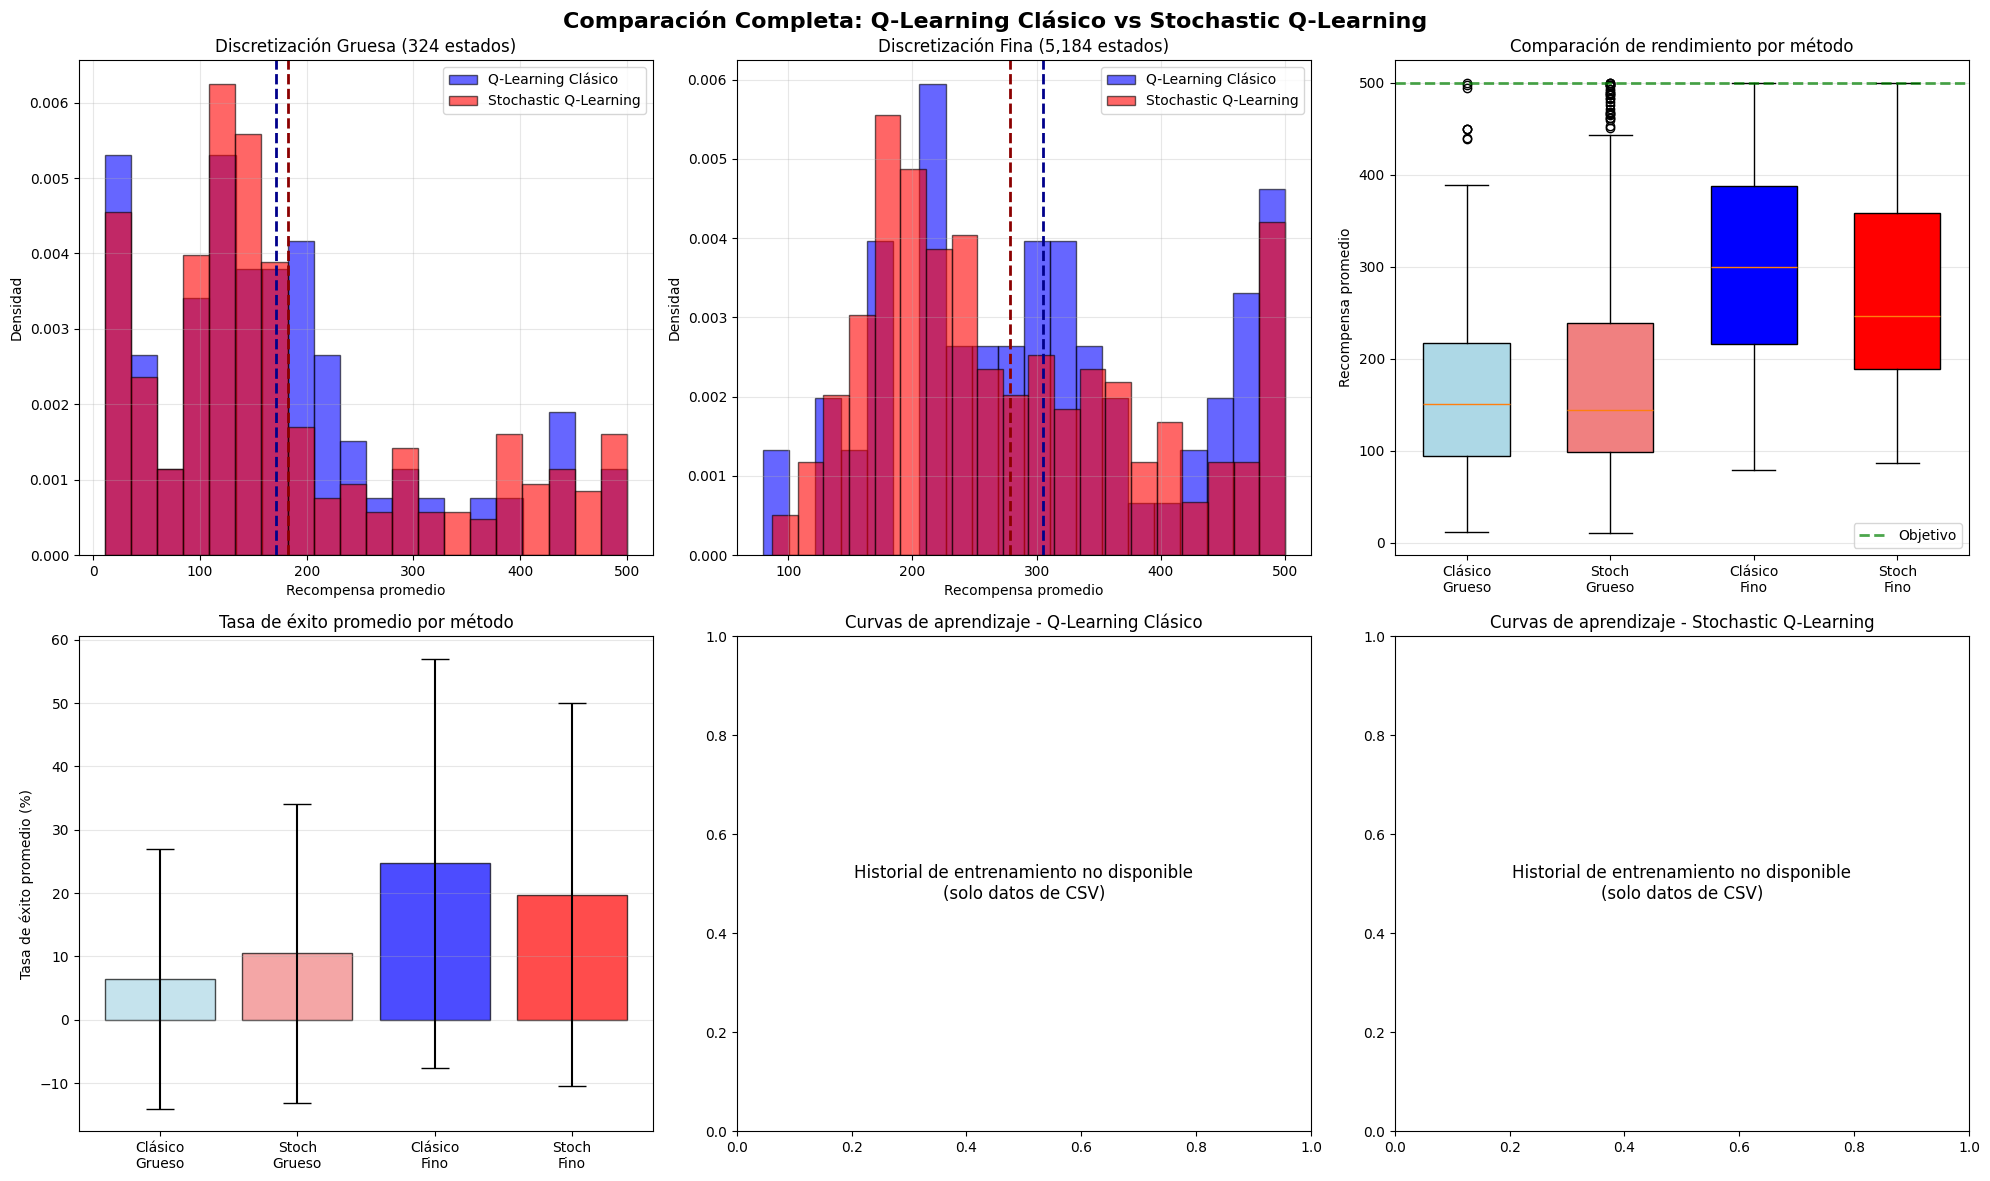

In [ ]:
# Visualización comparativa exhaustiva
# Preparar datos desde variables del kernel
coarse_classic_means = df_results_sorted['Eval_Mean'].values if 'df_results_sorted' in dir() else []
fine_classic_means = df_results_fine_sorted['Eval_Mean'].values if 'df_results_fine_sorted' in dir() else []
fine_stoch_means = df_stoch_fine_sorted['Eval_Mean'].values if 'df_stoch_fine_sorted' in dir() else []
coarse_stoch_means = df_stoch_coarse_sorted['Eval_Mean'].values if 'df_stoch_coarse_sorted' in dir() else []

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Comparación Completa: Q-Learning Clásico vs Stochastic Q-Learning', 
             fontsize=16, fontweight='bold')

# 1. Distribución de recompensas - Discretización Gruesa
axes[0, 0].hist(coarse_classic_means, bins=20, alpha=0.6, label='Q-Learning Clásico', 
                color='blue', edgecolor='black', density=True)
if len(coarse_stoch_means) > 0:
    axes[0, 0].hist(coarse_stoch_means, bins=20, alpha=0.6, label='Stochastic Q-Learning', 
                    color='red', edgecolor='black', density=True)
    axes[0, 0].axvline(np.mean(coarse_stoch_means), color='darkred', linestyle='--', linewidth=2)
axes[0, 0].axvline(np.mean(coarse_classic_means), color='darkblue', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Recompensa promedio')
axes[0, 0].set_ylabel('Densidad')
axes[0, 0].set_title('Discretización Gruesa (324 estados)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribución de recompensas - Discretización Fina
axes[0, 1].hist(fine_classic_means, bins=20, alpha=0.6, label='Q-Learning Clásico', 
                color='blue', edgecolor='black', density=True)
axes[0, 1].hist(fine_stoch_means, bins=20, alpha=0.6, label='Stochastic Q-Learning', 
                color='red', edgecolor='black', density=True)
axes[0, 1].axvline(np.mean(fine_classic_means), color='darkblue', linestyle='--', linewidth=2)
axes[0, 1].axvline(np.mean(fine_stoch_means), color='darkred', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Recompensa promedio')
axes[0, 1].set_ylabel('Densidad')
axes[0, 1].set_title('Discretización Fina (5,184 estados)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Box plots comparativos
if len(coarse_stoch_means) > 0:
    data_to_plot = [coarse_classic_means, coarse_stoch_means, fine_classic_means, fine_stoch_means]
    labels = ['Clásico\nGrueso', 'Stoch\nGrueso', 'Clásico\nFino', 'Stoch\nFino']
    colors = ['lightblue', 'lightcoral', 'blue', 'red']
else:
    data_to_plot = [coarse_classic_means, fine_classic_means, fine_stoch_means]
    labels = ['Clásico\nGrueso', 'Clásico\nFino', 'Stoch\nFino']
    colors = ['lightblue', 'blue', 'red']

bp = axes[0, 2].boxplot(data_to_plot, labels=labels, patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0, 2].axhline(y=500, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Objetivo')
axes[0, 2].set_ylabel('Recompensa promedio')
axes[0, 2].set_title('Comparación de rendimiento por método')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3, axis='y')

# 4. Tasas de éxito comparativas desde variables del kernel
success_classic_coarse = df_results_sorted['Success_%'].values if 'df_results_sorted' in dir() else []
success_classic_fine = df_results_fine_sorted['Success_%'].values if 'df_results_fine_sorted' in dir() else []
success_stoch_fine = df_stoch_fine_sorted['Success_%'].values if 'df_stoch_fine_sorted' in dir() else []
success_stoch_coarse = df_stoch_coarse_sorted['Success_%'].values if 'df_stoch_coarse_sorted' in dir() else []

if len(success_stoch_coarse) > 0:
    x_pos = np.arange(4)
    means = [np.mean(success_classic_coarse), np.mean(success_stoch_coarse), 
             np.mean(success_classic_fine), np.mean(success_stoch_fine)]
    stds = [np.std(success_classic_coarse), np.std(success_stoch_coarse), 
            np.std(success_classic_fine), np.std(success_stoch_fine)]
    colors_bar = ['lightblue', 'lightcoral', 'blue', 'red']
    labels_bar = ['Clásico\nGrueso', 'Stoch\nGrueso', 'Clásico\nFino', 'Stoch\nFino']
else:
    x_pos = np.arange(3)
    means = [np.mean(success_classic_coarse), np.mean(success_classic_fine), np.mean(success_stoch_fine)]
    stds = [np.std(success_classic_coarse), np.std(success_classic_fine), np.std(success_stoch_fine)]
    colors_bar = ['lightblue', 'blue', 'red']
    labels_bar = ['Clásico\nGrueso', 'Clásico\nFino', 'Stoch\nFino']

axes[1, 0].bar(x_pos, means, yerr=stds, align='center', alpha=0.7, 
               color=colors_bar, edgecolor='black', capsize=10)
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(labels_bar)
axes[1, 0].set_ylabel('Tasa de éxito promedio (%)')
axes[1, 0].set_title('Tasa de éxito promedio por método')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 5. Curvas de aprendizaje de los mejores modelos (solo si hay datos de historial)
if 'best_result' in dir() and 'best_result_fine' in dir() and 'rewards_history' in best_result and 'rewards_history' in best_result_fine:
    window = 100
    classic_coarse_smooth = np.convolve(best_result['rewards_history'], 
                                        np.ones(window)/window, mode='valid')
    classic_fine_smooth = np.convolve(best_result_fine['rewards_history'], 
                                      np.ones(window)/window, mode='valid')

    axes[1, 1].plot(classic_coarse_smooth, linewidth=2, label='Clásico Grueso', color='lightblue', alpha=0.8)
    axes[1, 1].plot(classic_fine_smooth, linewidth=2, label='Clásico Fino', color='blue', alpha=0.8)
    axes[1, 1].axhline(y=500, color='green', linestyle='--', linewidth=2, alpha=0.7)
    axes[1, 1].set_xlabel('Episodio de entrenamiento')
    axes[1, 1].set_ylabel('Recompensa (media móvil 100)')
    axes[1, 1].set_title('Curvas de aprendizaje - Q-Learning Clásico')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'Historial de entrenamiento no disponible\n(Ejecuta grid searches primero)', 
                    ha='center', va='center', fontsize=12, transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Curvas de aprendizaje - Q-Learning Clásico')

# 6. Curvas de aprendizaje - Stochastic Q-Learning
if 'best_result_stoch_fine' in dir() and 'rewards_history' in best_result_stoch_fine:
    window = 100
    if 'best_result_stoch_coarse' in dir() and 'rewards_history' in best_result_stoch_coarse:
        stoch_coarse_smooth = np.convolve(best_result_stoch_coarse['rewards_history'], 
                                          np.ones(window)/window, mode='valid')
        axes[1, 2].plot(stoch_coarse_smooth, linewidth=2, label='Stoch Grueso', color='lightcoral', alpha=0.8)

    stoch_fine_smooth = np.convolve(best_result_stoch_fine['rewards_history'], 
                                    np.ones(window)/window, mode='valid')
    axes[1, 2].plot(stoch_fine_smooth, linewidth=2, label='Stoch Fino', color='red', alpha=0.8)
    axes[1, 2].axhline(y=500, color='green', linestyle='--', linewidth=2, alpha=0.7)
    axes[1, 2].set_xlabel('Episodio de entrenamiento')
    axes[1, 2].set_ylabel('Recompensa (media móvil 100)')
    axes[1, 2].set_title('Curvas de aprendizaje - Stochastic Q-Learning')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
else:
    axes[1, 2].text(0.5, 0.5, 'Historial de entrenamiento no disponible\n(solo datos de CSV)', 
                    ha='center', va='center', fontsize=12, transform=axes[1, 2].transAxes)
    axes[1, 2].set_title('Curvas de aprendizaje - Stochastic Q-Learning')

plt.tight_layout()
plt.show()

## Exportación de Modelos

Se guardan los mejores modelos entrenados (tablas Q) en formato `.pkl` para su posterior uso y evaluación.

In [ ]:
import pickle
import os

# Crear carpeta models si no existe
os.makedirs('models', exist_ok=True)

print("="*100)
print("GUARDANDO MEJORES MODELOS ENTRENADOS")
print("="*100)

models_saved = []

# Guardar Q-Learning Clásico Grueso
if 'best_result' in dir() and 'Q_table' in best_result:
    model_path = 'models/q_learning_coarse_best.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump({
            'Q_table': best_result['Q_table'],
            'params': best_result['params'],
            'eval_mean': best_result['eval_mean'],
            'eval_std': best_result['eval_std'],
            'success_rate': best_result['success_rate'],
            'discretization': 'coarse',
            'n_states': (n_bins_cart_pos_coarse, n_bins_cart_vel_coarse, 
                        n_bins_pole_angle_coarse, n_bins_pole_ang_vel_coarse)
        }, f)
    models_saved.append(f"[OK] Q-Learning Clásico Grueso → {model_path}")
    print(f"[OK] Q-Learning Clásico Grueso guardado en: {model_path}")
    print(f"     Config: α={best_result['params']['alpha']}, γ={best_result['params']['gamma']}")
    print(f"     Rendimiento: {best_result['eval_mean']:.2f} ± {best_result['eval_std']:.2f}")
else:
    print("[PENDIENTE] Q-Learning Clásico Grueso: No disponible")

# Guardar Q-Learning Clásico Fino
if 'best_result_fine' in dir() and 'Q_table' in best_result_fine:
    model_path = 'models/q_learning_fine_best.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump({
            'Q_table': best_result_fine['Q_table'],
            'params': best_result_fine['params'],
            'eval_mean': best_result_fine['eval_mean'],
            'eval_std': best_result_fine['eval_std'],
            'success_rate': best_result_fine['success_rate'],
            'discretization': 'fine',
            'n_states': (n_bins_cart_pos_fine, n_bins_cart_vel_fine, 
                        n_bins_pole_angle_fine, n_bins_pole_ang_vel_fine)
        }, f)
    models_saved.append(f"[OK] Q-Learning Clásico Fino → {model_path}")
    print(f"\n[OK] Q-Learning Clásico Fino guardado en: {model_path}")
    print(f"     Config: α={best_result_fine['params']['alpha']}, γ={best_result_fine['params']['gamma']}")
    print(f"     Rendimiento: {best_result_fine['eval_mean']:.2f} ± {best_result_fine['eval_std']:.2f}")
else:
    print("\n[PENDIENTE] Q-Learning Clásico Fino: No disponible")

# Guardar Stochastic Q-Learning Grueso
if 'best_result_stoch_coarse' in dir() and 'Q_table' in best_result_stoch_coarse:
    model_path = 'models/stochastic_q_learning_coarse_best.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump({
            'Q_table': best_result_stoch_coarse['Q_table'],
            'params': best_result_stoch_coarse['params'],
            'eval_mean': best_result_stoch_coarse['eval_mean'],
            'eval_std': best_result_stoch_coarse['eval_std'],
            'success_rate': best_result_stoch_coarse['success_rate'],
            'discretization': 'coarse',
            'n_states': (n_bins_cart_pos_coarse, n_bins_cart_vel_coarse, 
                        n_bins_pole_angle_coarse, n_bins_pole_ang_vel_coarse)
        }, f)
    models_saved.append(f"[OK] Stochastic Q-Learning Grueso → {model_path}")
    print(f"\n[OK] Stochastic Q-Learning Grueso guardado en: {model_path}")
    print(f"     Config: α={best_result_stoch_coarse['params']['alpha']}, γ={best_result_stoch_coarse['params']['gamma']}, "
          f"k={best_result_stoch_coarse['params']['subset_size']}, memory={best_result_stoch_coarse['params']['use_memory']}")
    print(f"     Rendimiento: {best_result_stoch_coarse['eval_mean']:.2f} ± {best_result_stoch_coarse['eval_std']:.2f}")
else:
    print("\n[PENDIENTE] Stochastic Q-Learning Grueso: No disponible")

# Guardar Stochastic Q-Learning Fino
if 'best_result_stoch_fine' in dir() and 'Q_table' in best_result_stoch_fine:
    model_path = 'models/stochastic_q_learning_fine_best.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump({
            'Q_table': best_result_stoch_fine['Q_table'],
            'params': best_result_stoch_fine['params'],
            'eval_mean': best_result_stoch_fine['eval_mean'],
            'eval_std': best_result_stoch_fine['eval_std'],
            'success_rate': best_result_stoch_fine['success_rate'],
            'discretization': 'fine',
            'n_states': (n_bins_cart_pos_fine, n_bins_cart_vel_fine, 
                        n_bins_pole_angle_fine, n_bins_pole_ang_vel_fine)
        }, f)
    models_saved.append(f"[OK] Stochastic Q-Learning Fino → {model_path}")
    print(f"\n[OK] Stochastic Q-Learning Fino guardado en: {model_path}")
    print(f"     Config: α={best_result_stoch_fine['params']['alpha']}, γ={best_result_stoch_fine['params']['gamma']}, "
          f"k={best_result_stoch_fine['params']['subset_size']}, memory={best_result_stoch_fine['params']['use_memory']}")
    print(f"     Rendimiento: {best_result_stoch_fine['eval_mean']:.2f} ± {best_result_stoch_fine['eval_std']:.2f}")
else:
    print("\n[PENDIENTE] Stochastic Q-Learning Fino: No disponible")

print("\n" + "="*100)
print(f"RESUMEN: {len(models_saved)}/4 modelos guardados exitosamente")
print("="*100)

if len(models_saved) > 0:
    print("\nModelos disponibles en la carpeta 'models/':")
    for msg in models_saved:
        print(f"  {msg}")
    print("\nCada archivo .pkl contiene:")
    print("  - Q_table: Tabla Q entrenada (numpy array)")
    print("  - params: Hiperparámetros usados en entrenamiento")
    print("  - eval_mean, eval_std: Métricas de evaluación")
    print("  - success_rate: Tasa de éxito")
    print("  - discretization: 'coarse' o 'fine'")
    print("  - n_states: Dimensiones del espacio de estados")
else:
    print("\nNOTA: Ejecuta los grid searches para generar modelos antes de guardar.")